# Deep Learning for Natural Language Processing

## Angelos Dorotheos Chatzopoulos
## 7115112400027

### Python packages PIP installs

In [99]:
%pip install pandas
%pip install numpy
%pip install nltk
%pip install contractions
%pip install wordcloud
%pip install IPython
%pip install scikit-learn
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Python Packages Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from wordcloud import WordCloud
import re

import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import ngrams
import contractions
import string

import warnings
import sys
import os

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Exploratory Data Analysis (EDA)

### Function that plots a pie chart of the percentage of positive and negative labels of datasets

In [2]:
def plot_pie_chart(counts, title):
    counts = pd.Series(counts)
    counts.plot(kind='pie', autopct='%1.2f%%', figsize=(8, 8), colors=['darkorange', 'royalblue'])
    plt.title(title)
    plt.ylabel('Labels Distribution')
    plt.show()

### Function that plots a histogram that shows the distribution of tweets length across the dataset

In [3]:
def plot_histogram(data, x_label, y_label, title):
    plt.figure(figsize=(8, 6))
    plt.hist(data, bins=list(np.arange(0, 40, 5)), edgecolor='black', color='royalblue')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.xlim(0, 50)
    plt.axvline(data.mean(), color='k', linestyle='dashed', linewidth=1)
    _, max_ylim = plt.ylim()
    plt.text(data.mean()*1.1, max_ylim*0.9, 'Mean: {:.2f}'.format(data.mean()))
    plt.tight_layout()
    plt.show()

### Function that plots a wordcloud with the most common words of the dataset

In [4]:
def create_wordcloud(text):
    all_text = " ".join(text)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    plt.figure(figsize=(12, 10))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

### Function that plots a bar graph. Used for min-max tweets length and for finding the most common unigrams of the dataset

In [5]:
def plot_bar(categories, values, x_label, y_label, title, rotate=False, log_scale=False, show_vals=False, bary=False):
    plt.figure(figsize=(8, 6))
    
    if bary:
        bars = plt.barh(categories, values, edgecolor='black', color='royalblue')
    else:
        bars = plt.bar(categories, values, edgecolor='black', color='royalblue')
        
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    
    if show_vals:
         for bar in bars:
            plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bar.get_height() * 0.01, bar.get_height(),
                ha='center', va='bottom', color='black', fontsize=10)

    if log_scale:
        plt.yscale('log')

    if rotate:
        plt.xticks(rotation=-60)
        
    plt.tight_layout()
    plt.show()

### Function that plots two bar graphs. It is used to count the tweets bigrams and trigrams on the dataset

In [6]:
def subplot_bars(plot_1_values, plot_2_values, title, rotate=False, bary=False):
    _, axis = plt.subplots(1, 2, figsize=(18, 8))
    
    plt.suptitle(title, fontsize=15)
    
    if bary:
        axis[0].barh(plot_1_values[0], plot_1_values[1], edgecolor='black', color='royalblue')
    else:
        axis[0].bar(plot_1_values[0], plot_1_values[1], edgecolor='black', color='royalblue')

    axis[0].set_xlabel(plot_1_values[2])
    axis[0].set_ylabel(plot_1_values[3])
    
    if rotate:
        axis[0].tick_params(axis='x', labelrotation =-60)
    
    if bary:
        axis[1].barh(plot_2_values[0], plot_2_values[1], edgecolor='black', color='royalblue')
    else:
        axis[1].bar(plot_2_values[0], plot_2_values[1], edgecolor='black', color='royalblue')

    axis[1].set_xlabel(plot_2_values[2])
    axis[1].set_ylabel(plot_2_values[3])

    if rotate:
        axis[1].tick_params(axis='x', labelrotation =-60)
    
    plt.tight_layout()
    plt.show()

### Function that calculates for each row the length of the tweet text

In [7]:
def get_tweets_length(df):
    return df['Text'].str.split().str.len()

### Function that calculates and returns the top n-grams of a dataframe

In [8]:
def get_top_tokens(df, top, n=1):
    count_phrases = [word for tweet in df['Text'] for word in tweet.split()]
    ngram_2_tweets = pd.Series([word for word in ngrams(count_phrases, n)]).value_counts()
    top_10_phrases = ngram_2_tweets[:top]

    top_10_tokens_names = [' '.join(x) for x in top_10_phrases.index]
    top_10_tokens_freq = list(top_10_phrases)
    return top_10_tokens_names, top_10_tokens_freq

### Function that finds the minimum and maximum tweet length and returns a new dataframe

In [9]:
def get_min_max_tweets(t_length):
    return pd.DataFrame({
        'Minimum Tweet Length': [t_length.min()],
        'Maximum Tweet Length': [t_length.max()],
    })

### Load train, validation and test datasets from CSV files into dataframes

In [10]:
df_train = pd.read_csv('./data/train_dataset.csv')
df_val = pd.read_csv('./data/val_dataset.csv')
df_test = pd.read_csv('./data/test_dataset.csv')

### Extract tweets and labels from the dataframes

In [11]:
X_train, y_train = df_train['Text'], df_train['Label']

X_val, y_val = df_val['Text'], df_val['Label']

X_test = df_test['Text']

### Displaying the dimensions of dataframes

In [12]:
print(f'Training dataset dimensions: {df_train.shape}')
print(f'Validate dataset dimensions: {df_val.shape}')
print(f'Test dataset dimensions: {df_test.shape}')

Training dataset dimensions: (148388, 3)
Validate dataset dimensions: (42396, 3)
Test dataset dimensions: (21199, 2)


### Displaying metadata information about Train dataframe

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148388 entries, 0 to 148387
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   ID      148388 non-null  int64 
 1   Text    148388 non-null  object
 2   Label   148388 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB


### Displaying metadata information about Validation dataframe

In [14]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42396 entries, 0 to 42395
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      42396 non-null  int64 
 1   Text    42396 non-null  object
 2   Label   42396 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 993.8+ KB


### Checking the top 5 rows of the train set

In [15]:
df_train.head()

,ID,Text,Label
0,189385,@whoisralphie dude I'm so bummed ur leaving!,0
1,58036,"oh my god, a severed foot was foun in a wheely...",0
2,190139,I end up &quot;dog dialing&quot; sumtimes. Wha...,1
3,99313,@_rachelx meeeee toooooo!,0
4,157825,"I was hoping I could stay home and work today,...",0


### Checking the top 5 rows of the validation set

In [16]:
df_val.head()

,ID,Text,Label
0,187062,@NatexTheGreat heyheyhey maybe i will get the...,0
1,168997,@molliesmummy Work? Work was crap. I missed yo...,0
2,194461,Want: Trip to Boston next month. Need: Addit'l...,1
3,165442,first day starts tomorrow!,1
4,34853,@goodforyoursoul 8 course fish in Little Saigo...,1


### We observe that train & validation datasets do not have any empty or duplicated rows

In [17]:
print('Train Set')
display(df_train.isnull().sum())
display(df_train.duplicated().sum())

print('Validation Set')
display(df_val.isnull().sum())
display(df_val.duplicated().sum())

Train Set


ID       0
Text     0
Label    0
dtype: int64

np.int64(0)

Validation Set


ID       0
Text     0
Label    0
dtype: int64

np.int64(0)

## Exploratory Data Analysis Before Text Preprocessing

### Plotting the distribution of sentiment categories in dataset. We notice that positive & negative labels are equally distributed

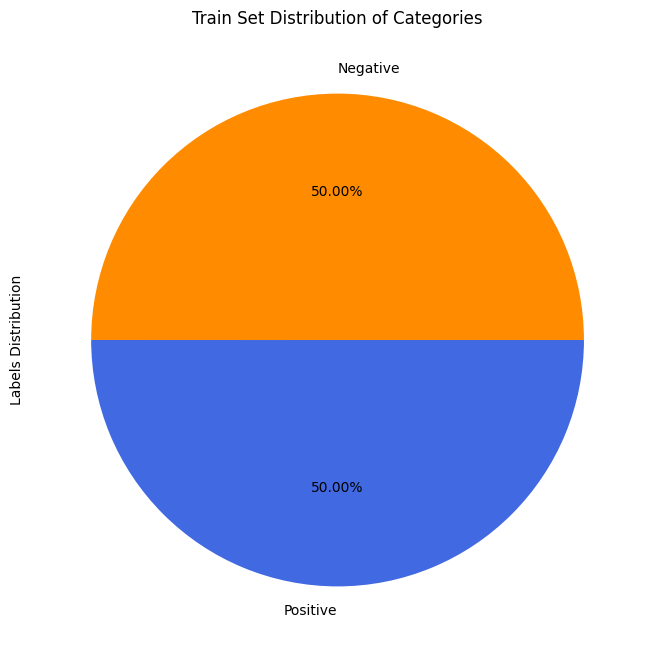

In [18]:
labels_count = df_train['Label'].value_counts()
negative_tweets = labels_count[0]
positive_tweets = labels_count[1]

plot_pie_chart({'Negative': negative_tweets, 'Positive': positive_tweets}, 'Train Set Distribution of Categories')

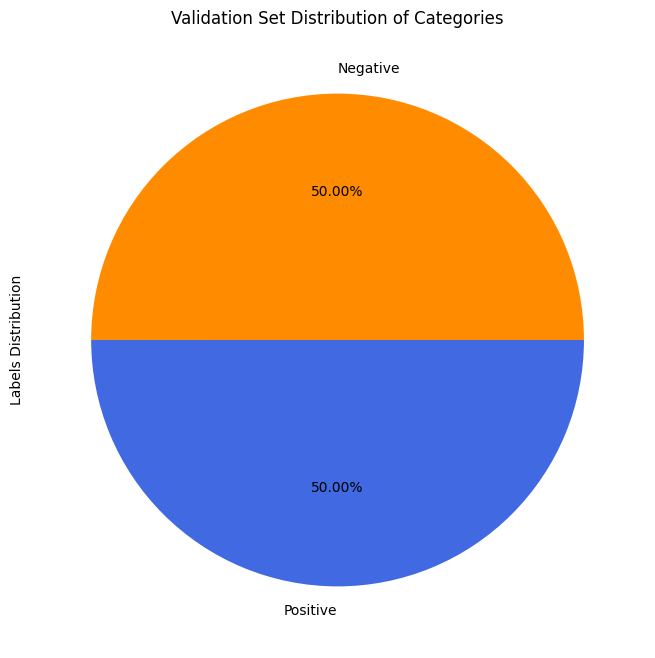

In [19]:
labels_count = df_val['Label'].value_counts()
negative_tweets = labels_count[0]
positive_tweets = labels_count[1]

plot_pie_chart({'Negative': negative_tweets, 'Positive': positive_tweets}, 'Validation Set Distribution of Categories')

### Creating a wordcloud using the tweet texts on train set before preprocessing

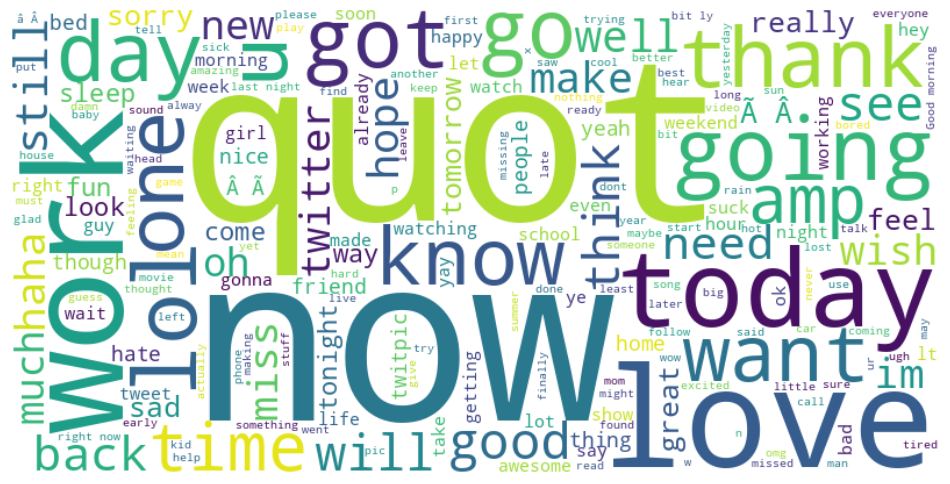

In [20]:
create_wordcloud(df_train['Text'])

### Creating a wordcloud by using only the positive tweets before preprocessing

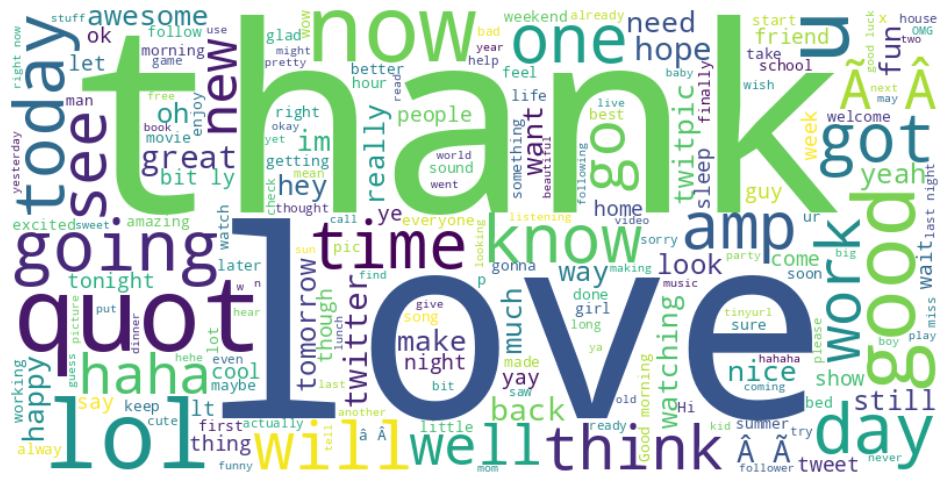

In [21]:
create_wordcloud(df_train[df_train['Label'] == 1]['Text'])

### Creating a wordcloud by using only the negative tweets before preprocessing

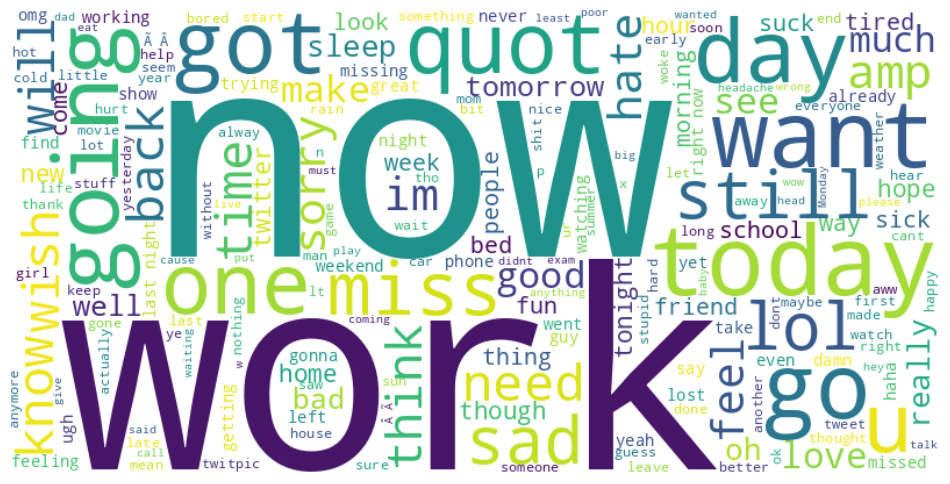

In [22]:
create_wordcloud(df_train[df_train['Label'] == 0]['Text'])

### Plotting a histogram with tweets length across the dataset

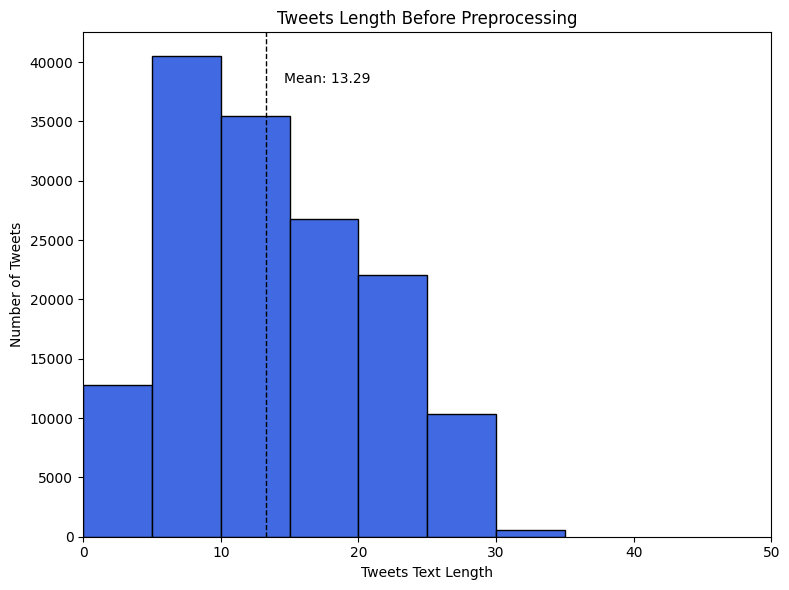

In [23]:
tweets_length = get_tweets_length(df_train)
plot_histogram(tweets_length, 'Tweets Text Length', 'Number of Tweets', 'Tweets Length Before Preprocessing')

### Plotting minimum and maximum length of tweets on train set

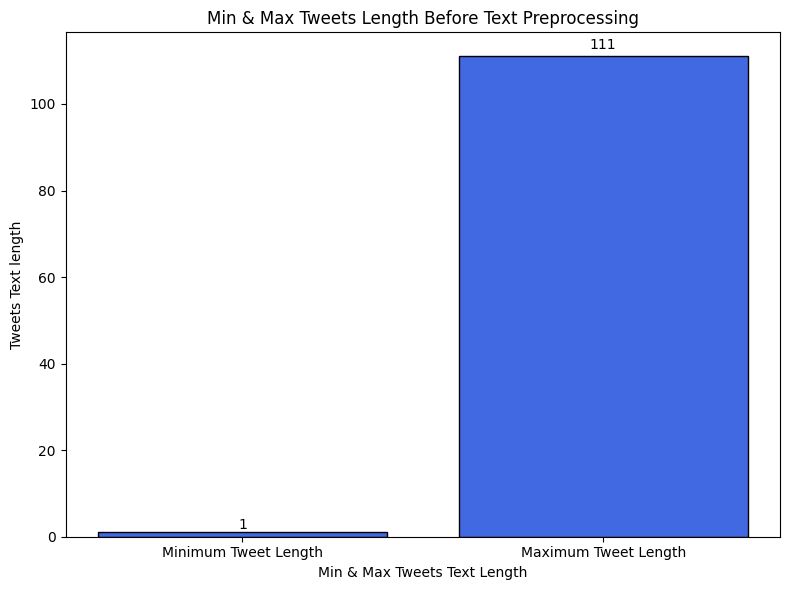

In [24]:
df_min_max = get_min_max_tweets(tweets_length)
plot_bar(list(df_min_max.columns), df_min_max.iloc[0, :].values.tolist(), 'Min & Max Tweets Text Length', 'Tweets Text length', 'Min & Max Tweets Length Before Text Preprocessing', False, False, True)

### Plotting the most common words (unigrams) of train dataset

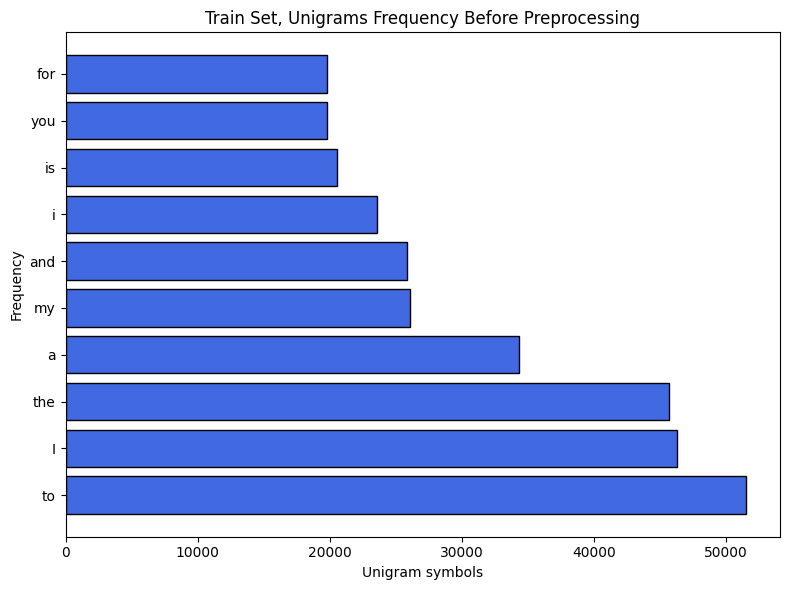

In [25]:
bar_plots_1ngrams = [res for res in get_top_tokens(df_train, top=10, n=1)] + ['Unigram symbols', 'Frequency']
plot_bar(bar_plots_1ngrams[0], bar_plots_1ngrams[1], bar_plots_1ngrams[2], bar_plots_1ngrams[3], 'Train Set, Unigrams Frequency Before Preprocessing', bary=True)

### Plotting the most common tokens (bigrams and trigrams) of train dataset

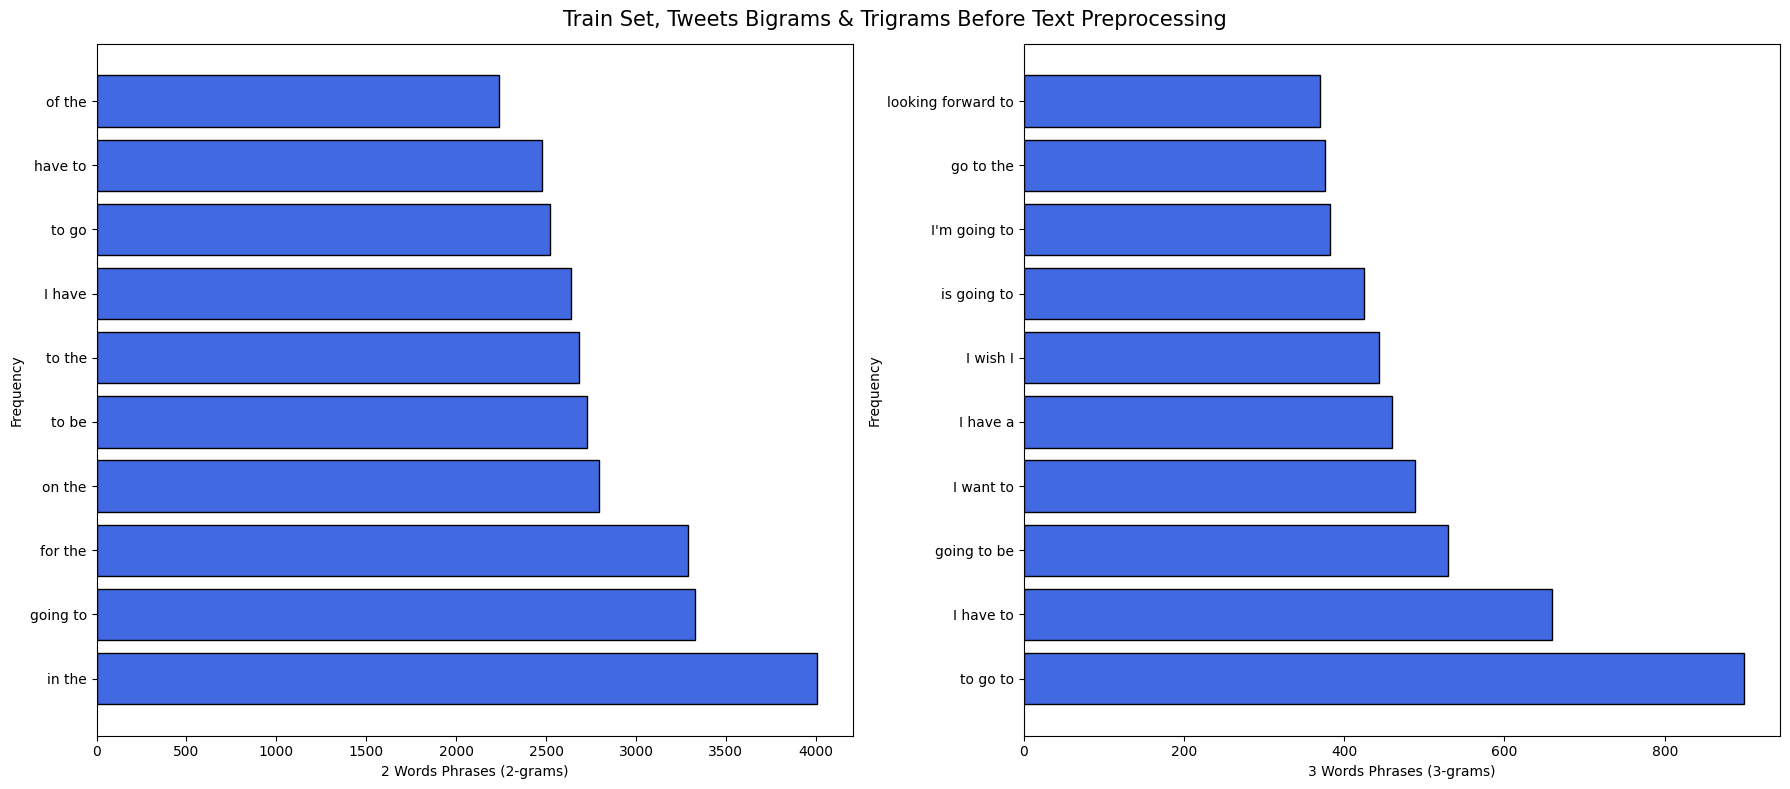

In [26]:
bar_plots_2ngrams = [res for res in get_top_tokens(df_train, top=10, n=2)] + ['2 Words Phrases (2-grams)', 'Frequency']
bar_plots_3ngrams = [res for res in get_top_tokens(df_train, top=10, n=3)] + ['3 Words Phrases (3-grams)', 'Frequency']

subplot_bars(bar_plots_2ngrams, bar_plots_3ngrams, 'Train Set, Tweets Bigrams & Trigrams Before Text Preprocessing', bary=True)

### Plotting the number of emails and user mentions found in train dataset (Log Scale)

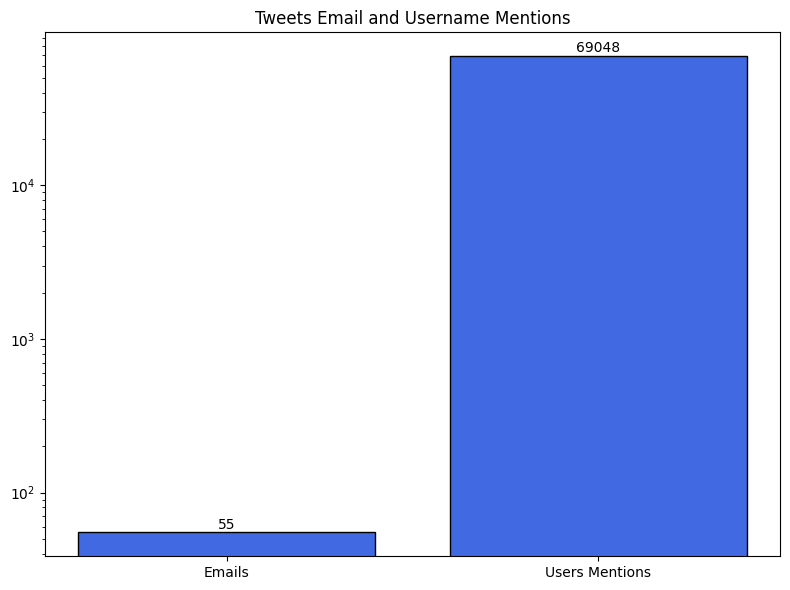

In [27]:
emails_count = df_train.loc[df_train['Text'].str.contains(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{1,}\b'), :].shape[0]

user_mentions_count = df_train.loc[df_train['Text'].str.contains(r'(?<![\w.])@\w+'), :].shape[0]

plot_bar(['Emails', 'Users Mentions'], [emails_count, user_mentions_count], '', '', 'Tweets Email and Username Mentions', False, True, True)

## NLP Text Preprocessing on Tweets

In [28]:
nltk.download('punkt', quiet=True);
nltk.download('stopwords', quiet=True);
nltk.download('wordnet', quiet=True);

### Text Preprocessing is done on two phases:
- Preprocessing with stop words filtering
- Preprocessing with stop words preservation

### The `preprocess_text` function applies the following preprocessing steps:
- **Lowercasing**: Converts all characters to lowercase.
- **Expanding Contractions**: Expanding combinations of words that are shortened.
- **Removing Punctuation Except '@' for Emails and User Mentions**: Eliminating the punctuation of tweets.
- **Anonymizing Mentions**: Username mentions in tweets are converted to '@user'.
- **Anonymizing Email Addresses**: Email addresses are converted to 'XXX@email.com'.
- **Removing URLs**: Removing URLs from text.
- **Removing Digits**: Removing all numeric characters within tweets.
- **Filtering Stop Words**: If 'filter_stopwords' is true then stop words are removed from tweets.
- **Lemmatization**: Coverts the words to their base form.

In [29]:
punctuation = string.punctuation.replace('@', '')
lemmatizer = WordNetLemmatizer()
tokenizer = TweetTokenizer()

def preprocess_text(text, filter_stopwords):
    text = text.lower()
    text = contractions.fix(text)
    
    text = text.translate(str.maketrans('', '', punctuation))

    text = re.sub(r'(?<![\w.])@\w+', '@user', text)
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\b', "XXX@email.com", text)
    
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r'\d+', '', text)
    
    tokens = tokenizer.tokenize(text)
    
    if filter_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

### Removing rows with zero text length (after doing preprocessing) only on train and validation datasets

In [30]:
def filter_non_empty(df):
    return df[df['Text'].str.split().str.len() != 0]

### Function `clean_dataset` does the following steps:
- Creates a copy of the dataframe.
- Removes non-ascii characters from tweets.
- Runs the `preprocess_text` function to further preprocess the tweets (explained above).
- Removes any row with zero text length (on train and validation set only).

In [31]:
def clean_dataset(df, filter_stopwords=False, filter_rows=True):
    df_clean = df.copy()
    df_clean['Text'] = df_clean['Text'].str.encode('ascii', 'ignore').str.decode('ascii')
    df_clean['Text'] = df_clean['Text'].apply(preprocess_text, filter_stopwords=filter_stopwords)
    return filter_non_empty(df_clean) if filter_rows else df_clean

### Running tweets preprocessing on train, validation and test set with filtering stop words activated

In [32]:
df_train_cln = clean_dataset(df_train, filter_stopwords=True)
df_val_cln = clean_dataset(df_val, filter_stopwords=True)
df_test_cln = clean_dataset(df_test, filter_stopwords=True, filter_rows=False)

X_train_prep, y_train_prep = df_train_cln['Text'], df_train_cln['Label']
X_val_prep, y_val_prep   = df_val_cln['Text'], df_val_cln['Label']
X_test_prep = df_test_cln['Text']

### Displaying the dimenstions of train, validation and test dataset matrices

In [33]:
print(f"X train Preprocessed Dimensions: {X_train_prep.shape}")
print(f"y train Preprocessed Dimensions: {y_train_prep.shape}")

print(f"X validation Preprocessed Dimensions: {X_val_prep.shape}")
print(f"y validation Preprocessed Dimensions: {y_val_prep.shape}")

print(f"X test Preprocessed Dimensions: {X_test_prep.shape}")

X train Preprocessed Dimensions: (148339,)
y train Preprocessed Dimensions: (148339,)
X validation Preprocessed Dimensions: (42385,)
y validation Preprocessed Dimensions: (42385,)
X test Preprocessed Dimensions: (21199,)


### Checking the tweets after running preprocessing

In [34]:
df_train_cln.head()

,ID,Text,Label
0,189385,@user dude bummed leaving,0
1,58036,oh god severed foot foun wheely bin cobham fou...,0
2,190139,end quotdog dialingquot sumtimes dog dialing a...,1
3,99313,@user meeeee toooooo,0
4,157825,hoping could stay home work today look like ma...,0


In [35]:
df_val_cln.head()

,ID,Text,Label
0,187062,@user heyheyhey maybe get could find @user wou...,0
1,168997,@user work work crap missed condescending over...,0
2,194461,want trip boston next month need additl motiva...,1
3,165442,first day start tomorrow,1
4,34853,@user course fish little saigon dessert place ...,1


## Exploratory Data Analysis After Running Text Preprocessing (With Stop Words Filtering)

### Plotting a histogram with tweets length across the training dataset after preprocessing

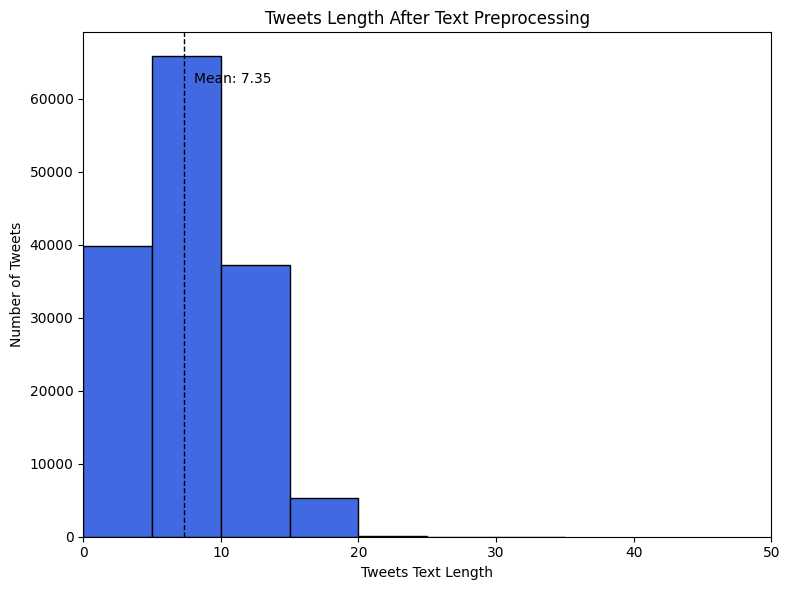

In [36]:
tweets_length_clean = get_tweets_length(df_train_cln)
plot_histogram(tweets_length_clean, 'Tweets Text Length', 'Number of Tweets', 'Tweets Length After Text Preprocessing')

### Plotting minimum and maximum length of tweets after running preprocessing

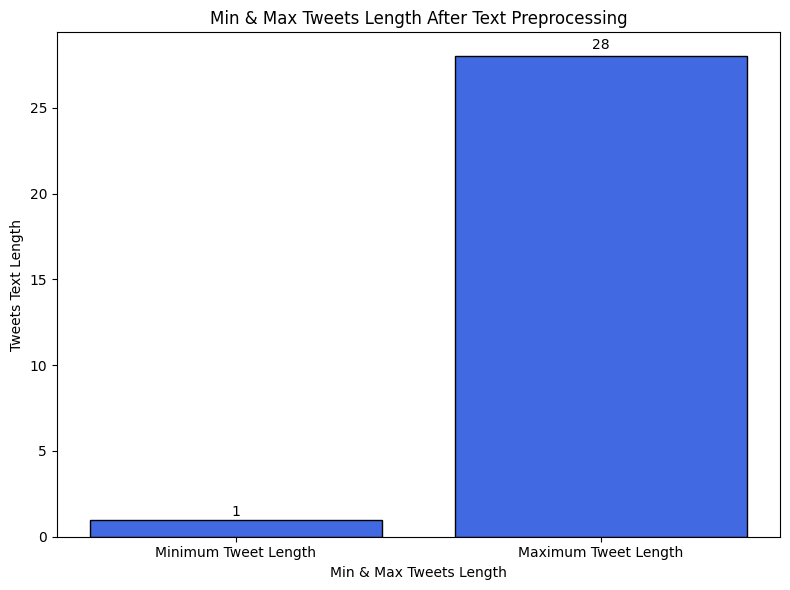

In [37]:
df_min_max = get_min_max_tweets(tweets_length_clean)
plot_bar(list(df_min_max.columns), df_min_max.iloc[0, :].values.tolist(), 'Min & Max Tweets Length', 'Tweets Text Length', 'Min & Max Tweets Length After Text Preprocessing', False, False, True)

### Creating a wordcloud using the tweet texts on train set after running preprocessing

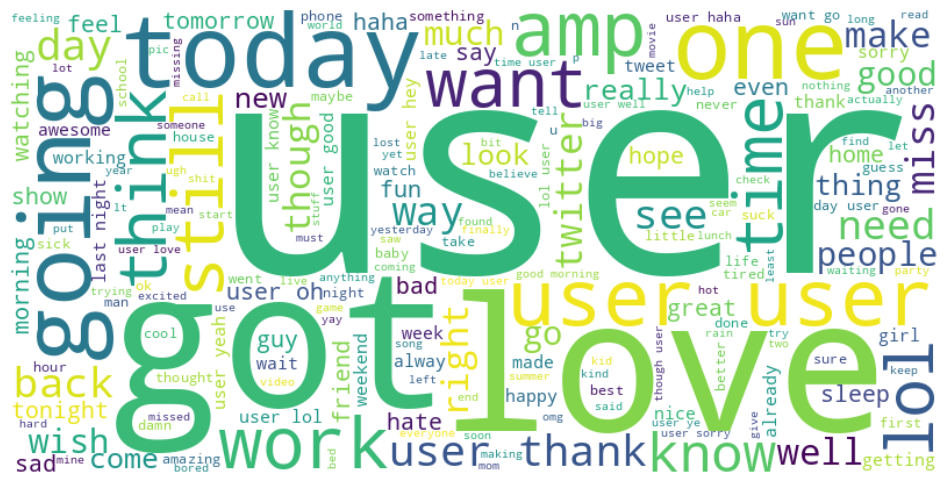

In [38]:
create_wordcloud(df_train_cln['Text'])

### Creating a wordcloud by using only the positive tweets after running preprocessing

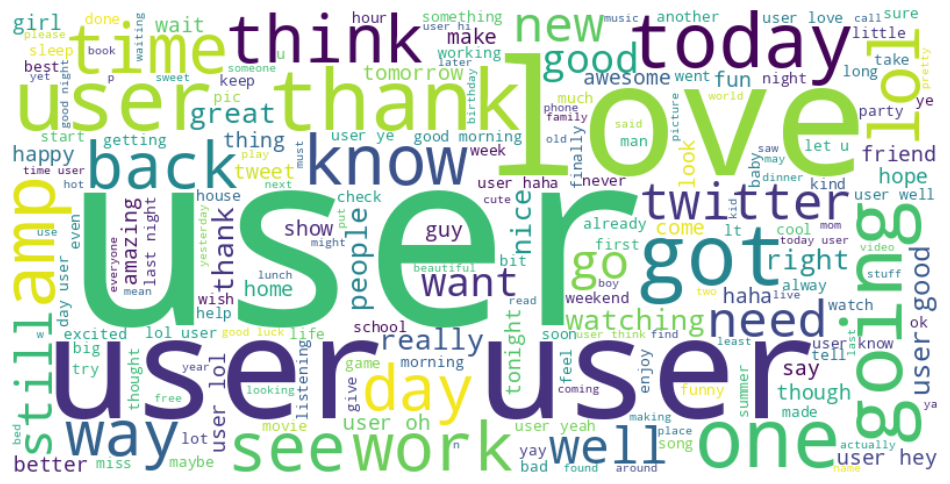

In [39]:
create_wordcloud(df_train_cln[df_train_cln['Label'] == 1]['Text'])

### Creating a wordcloud by using only the negative tweets after running preprocessing

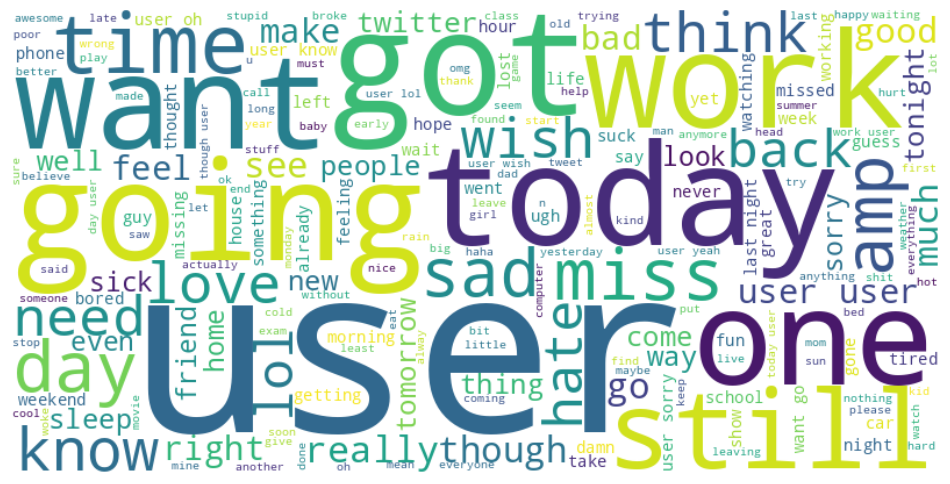

In [40]:
create_wordcloud(df_train_cln[df_train_cln['Label'] == 0]['Text'])

### Plotting the most common words (unigrams) of train dataset after running preprocessing

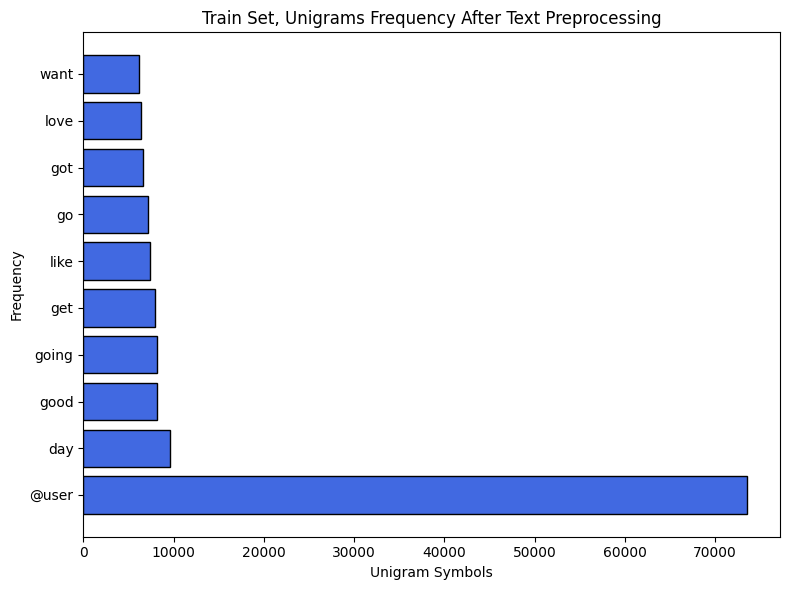

In [41]:
bar_plots_1ngrams = [res for res in get_top_tokens(df_train_cln, top=10, n=1)] + ['Unigram Symbols', 'Frequency']
plot_bar(bar_plots_1ngrams[0], bar_plots_1ngrams[1], bar_plots_1ngrams[2], bar_plots_1ngrams[3], 'Train Set, Unigrams Frequency After Text Preprocessing', bary=True)

### Plotting the most common tokens (bigrams and trigrams) of train dataset after running preprocessing

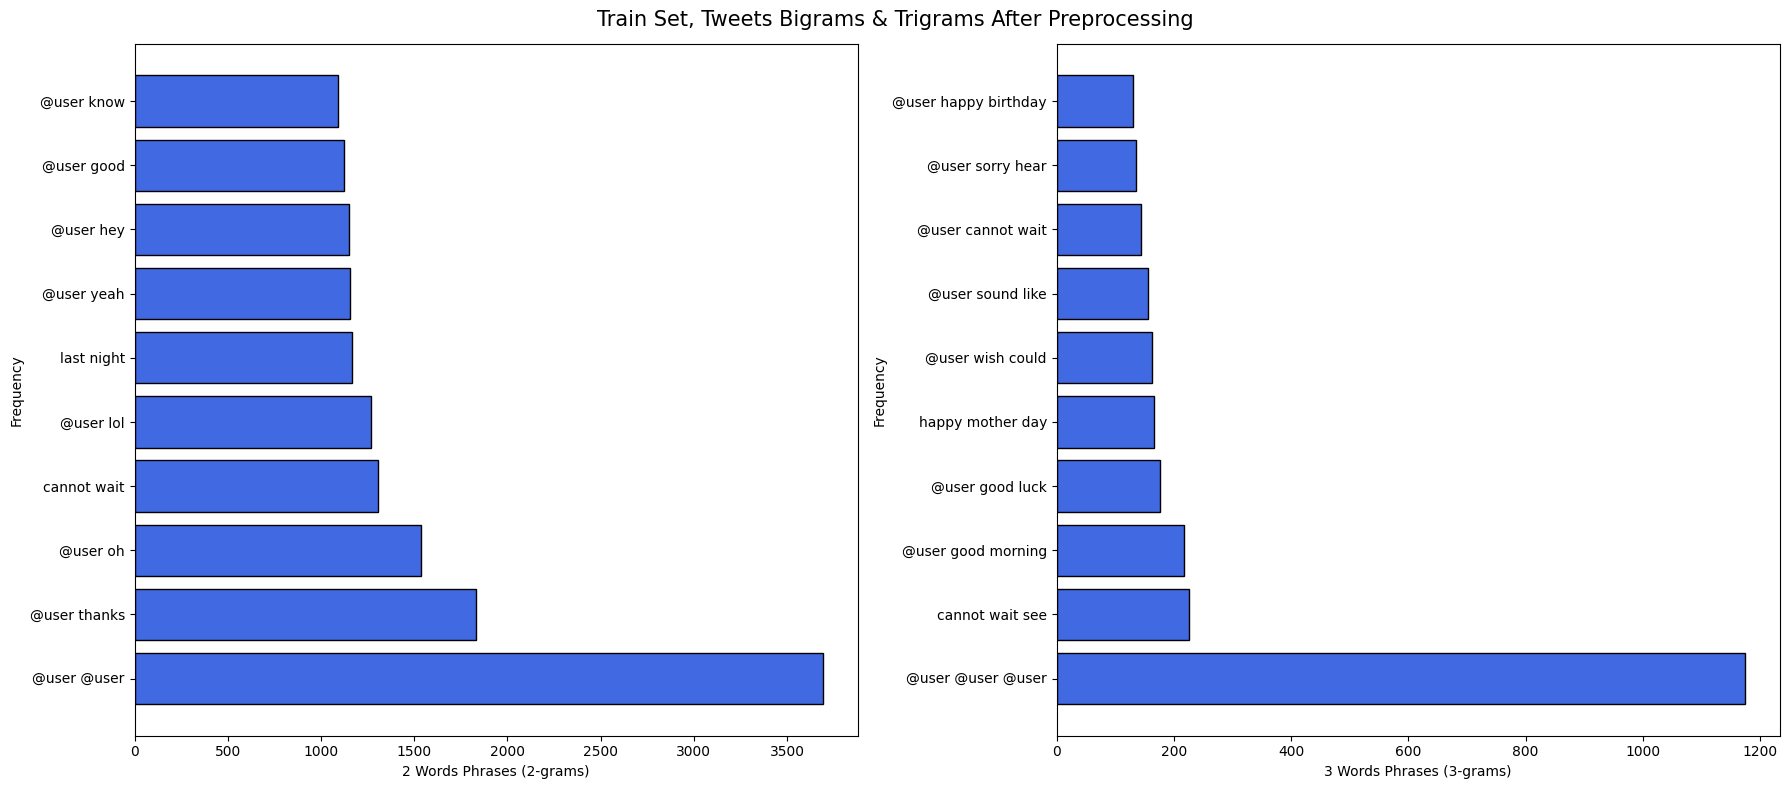

In [42]:
bar_plots_2ngrams = [res for res in get_top_tokens(df_train_cln, top=10, n=2)] + ['2 Words Phrases (2-grams)', 'Frequency']
bar_plots_3ngrams = [res for res in get_top_tokens(df_train_cln, top=10, n=3)] + ['3 Words Phrases (3-grams)', 'Frequency']

subplot_bars(bar_plots_2ngrams, bar_plots_3ngrams, 'Train Set, Tweets Bigrams & Trigrams After Preprocessing', bary=True)

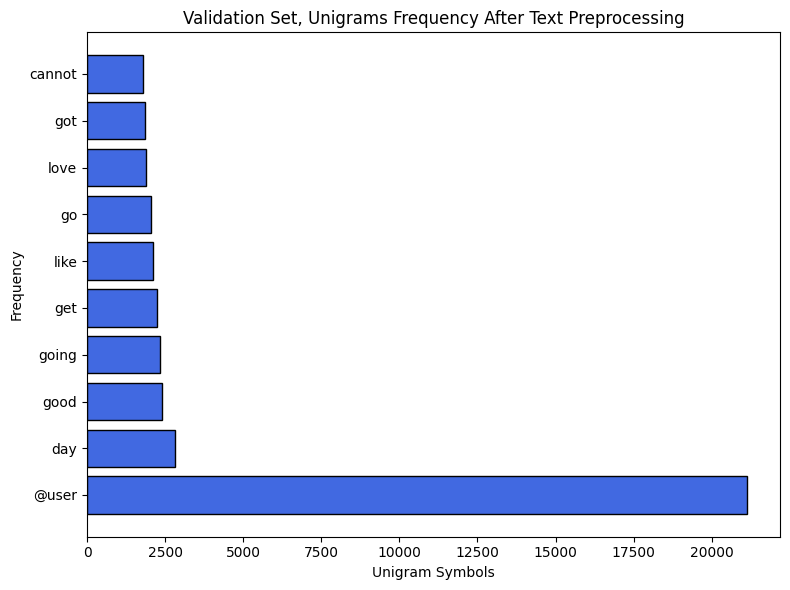

In [43]:
bar_plots_1ngrams = [res for res in get_top_tokens(df_val_cln, top=10, n=1)] + ['Unigram Symbols', 'Frequency']
plot_bar(bar_plots_1ngrams[0], bar_plots_1ngrams[1], bar_plots_1ngrams[2], bar_plots_1ngrams[3], 'Validation Set, Unigrams Frequency After Text Preprocessing', bary=True)

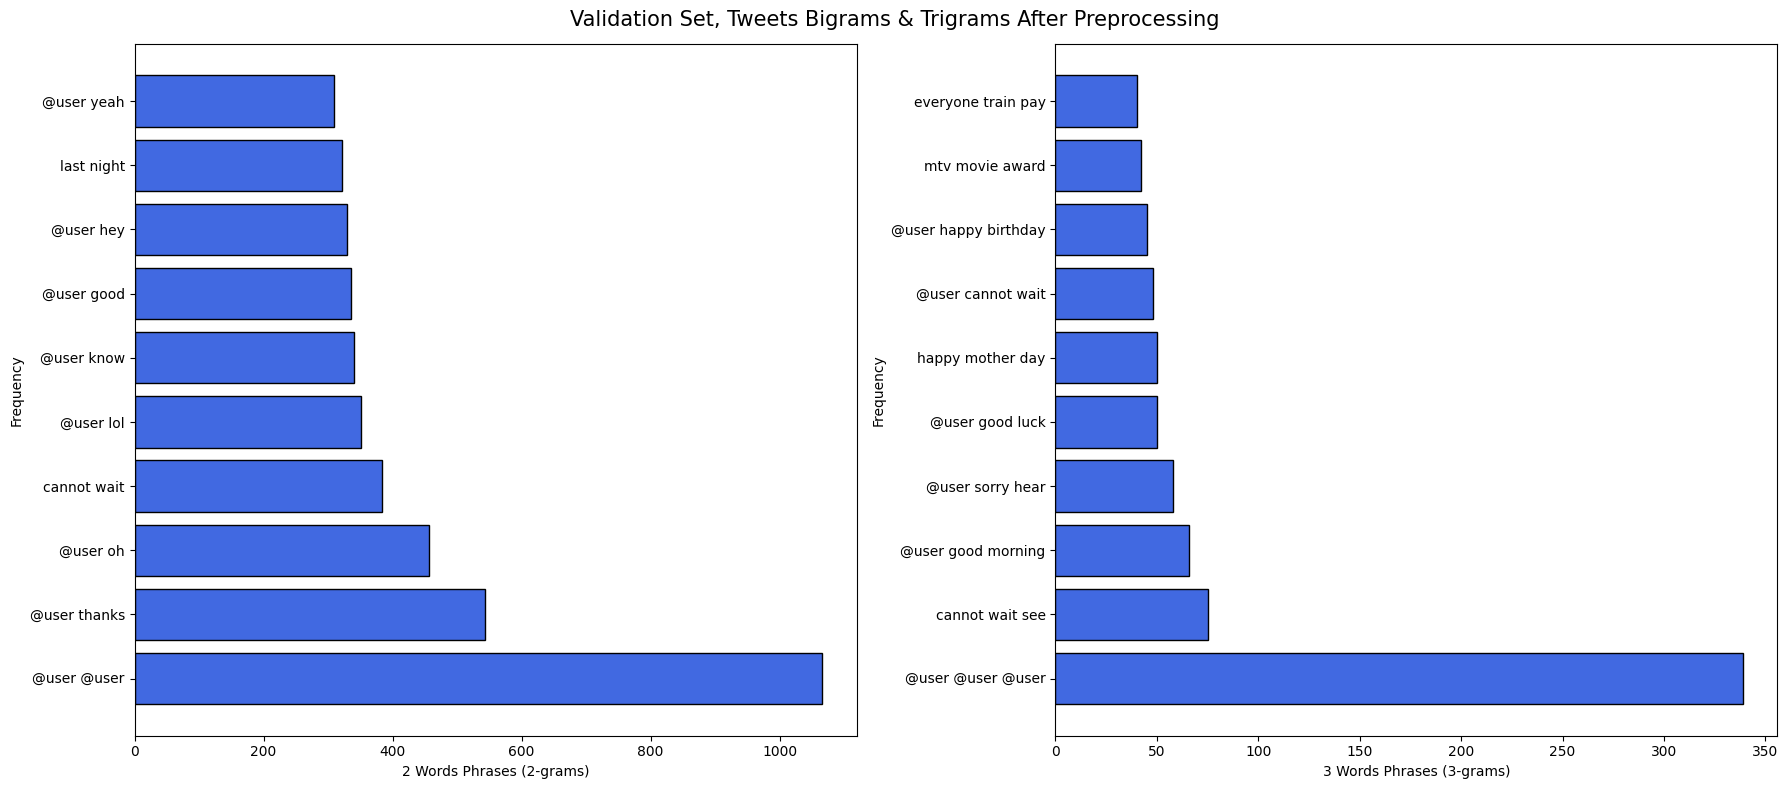

In [44]:
bar_plots_2ngrams = [res for res in get_top_tokens(df_val_cln, top=10, n=2)] + ['2 Words Phrases (2-grams)', 'Frequency']
bar_plots_3ngrams = [res for res in get_top_tokens(df_val_cln, top=10, n=3)] + ['3 Words Phrases (3-grams)', 'Frequency']

subplot_bars(bar_plots_2ngrams, bar_plots_3ngrams, 'Validation Set, Tweets Bigrams & Trigrams After Preprocessing', bary=True)

## Feature Extraction: TF-IDF Hyperparameters Tuning

### Function that calculates **Accuracy**, **Precission**, **Recall** and **F1 scores** and returns a dictionary object

In [45]:
def calc_model_score(y_true, y_pred):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }
    return metrics

### Function that creates multiple subplot bar graphs to display model scores for each hyperparameter configuration 

In [46]:
def subplot_scores(metrics_list, titles, title, rows=2, cols=2, figsize=(12,10)):
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    fig.suptitle(title, fontsize=15)
    
    if rows * cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    colors_list = ['#1C77C3', '#F34213', '#E0CA3C', '#3E2F5B']

    for ax, metrics, sub_title in zip(axes, metrics_list, titles):
        bars = ax.bar(list(metrics.keys()), [value * 100 for value in metrics.values()], color=colors_list, edgecolor='black')

        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{height:.2f}%", ha='center', va='bottom')
        
        ax.set_ylabel("Score")
        ax.set_ylim(0, 110)
        ax.set_title(sub_title)
        
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

### Function that calculates the learning curve, given a model configuration

In [47]:
def calc_learning_curve(model_conf, X, Y):
    train_sizes, train_scores, cv_scores = learning_curve(model_conf, X, Y, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    cv_mean = np.mean(cv_scores, axis=1)
    cv_std = np.std(cv_scores, axis=1)

    return train_sizes, train_mean, train_std, cv_mean, cv_std

### Function that plots the learning curve graph

In [48]:
def plot_learning_curve(train_sizes, train_mean, train_std, cv_mean, cv_std, title):
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label="Training Score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, cv_mean, 'o-', color='green', label="Validation Score")
    plt.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.1, color='green')
    
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy Score")
    plt.title(title)
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

### Function that calculates the ROC curve

In [49]:
def calc_roc_curve(y, y_pred):
    fpr, tpr, _ = roc_curve(y, y_pred)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

### Function that plots the ROC curve

In [50]:
def plot_roc_curve(fpr, tpr, roc_auc, estimator_name):
    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=estimator_name)
    display.plot()
    plt.show()

### Function that calculates the confusion matrix, given the classification labels

In [51]:
def calc_confusion_matrix(y, y_pred, clf):
    return confusion_matrix(y, y_pred, labels=clf.classes_)

### Function that plots the confusion matrix

In [52]:
def plot_confusion_matrix(cm, clf):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp.plot()
    plt.show()

## Experimenting on TF-IDF Hyperparameters on default Logistic Regression hyperparameters

#### The acronyms used on preprocessing experimentations are the following: 

#### - **NPR**: No Preprocessing
#### - **PRFS**: Preprocessing & Filtering Stopwords
#### - **PRPS**: Preprocessing & Preserving Stopwords

### Function that helps running experiments on TF-IDF hyperparametes

In [53]:
def test_tfidf(params, X_train, y_train, X_val, y_val):
    scores_list = []

    for param in params:

        vectorizer = TfidfVectorizer(**param)
        X_train_tfidf = vectorizer.fit_transform(X_train)

        logistic = LogisticRegression(random_state=42, n_jobs=-1)

        logistic.fit(X_train_tfidf, y_train)

        X_val_tfidf = vectorizer.transform(X_val)
        y_pred = logistic.predict(X_val_tfidf)

        scores_list.append(calc_model_score(y_val, y_pred))

    return scores_list

### Experimenting without tweets preprocessing **(NPR)** & TF-IDF `ngram_range` hyperparameter

In [54]:
tfidf_params = [
    {'ngram_range': (1, 1)},
    {'ngram_range': (1, 2)},
    {'ngram_range': (2, 2)},
    {'ngram_range': (2, 3)}
]

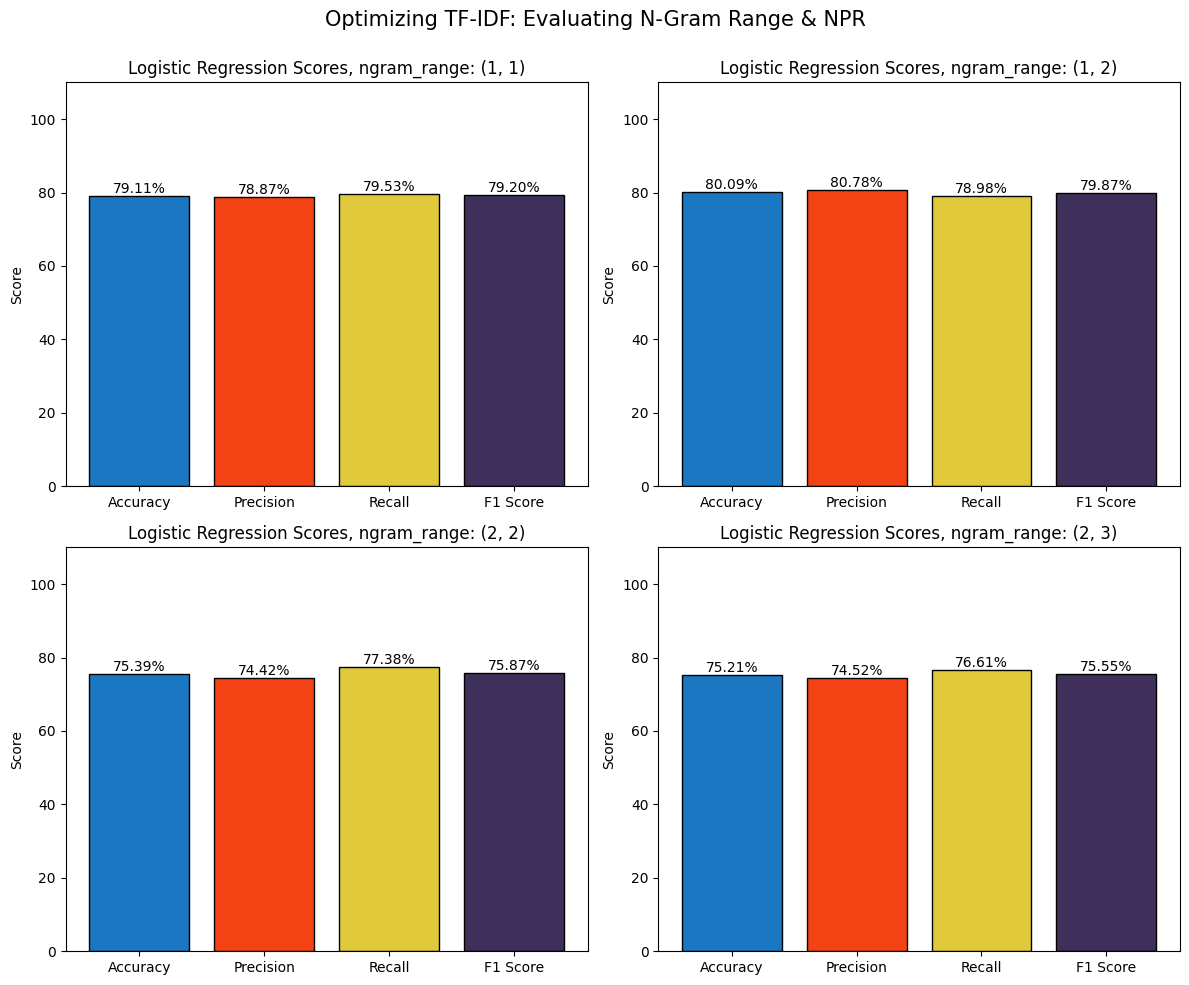

In [55]:
scores = test_tfidf(tfidf_params, X_train, y_train, X_val, y_val)
titles = [f"Logistic Regression Scores, {key}: {val}" for param in tfidf_params for key, val in param.items()]
title = 'Optimizing TF-IDF: Evaluating N-Gram Range & NPR'
subplot_scores(scores, titles, title)

### Learning curve on the best `ngram_range: (1, 2)` hyperparameter configuration using the Training dataset **(NPR)**

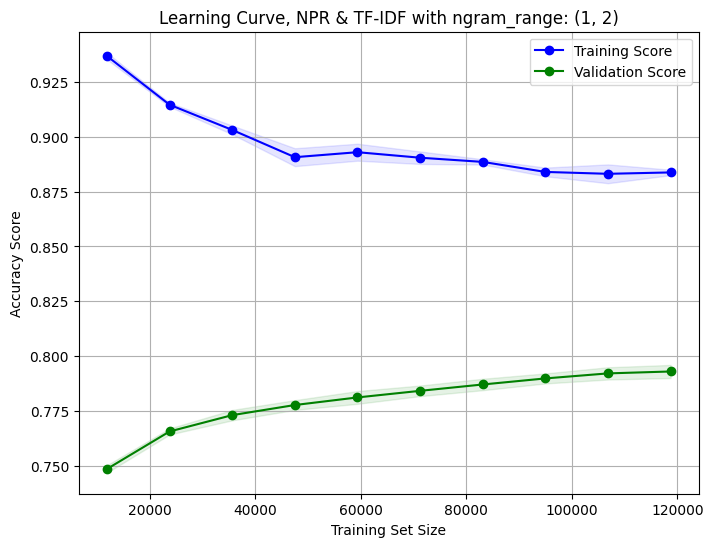

In [56]:
vectorizer = TfidfVectorizer(**tfidf_params[1])
X_train_tfidf = vectorizer.fit_transform(X_train)

lc_res = calc_learning_curve(LogisticRegression(random_state=42, n_jobs=-1), X_train_tfidf, y_train)
title = f'Learning Curve, NPR & TF-IDF with {list(tfidf_params[1].keys())[0]}: {list(tfidf_params[1].values())[0]}'

plot_learning_curve(*lc_res, title)

### Experimenting on preprocessed tweets with filtered stopwords **(PRFS)** on TF-IDF `ngram_range` hyperparameter

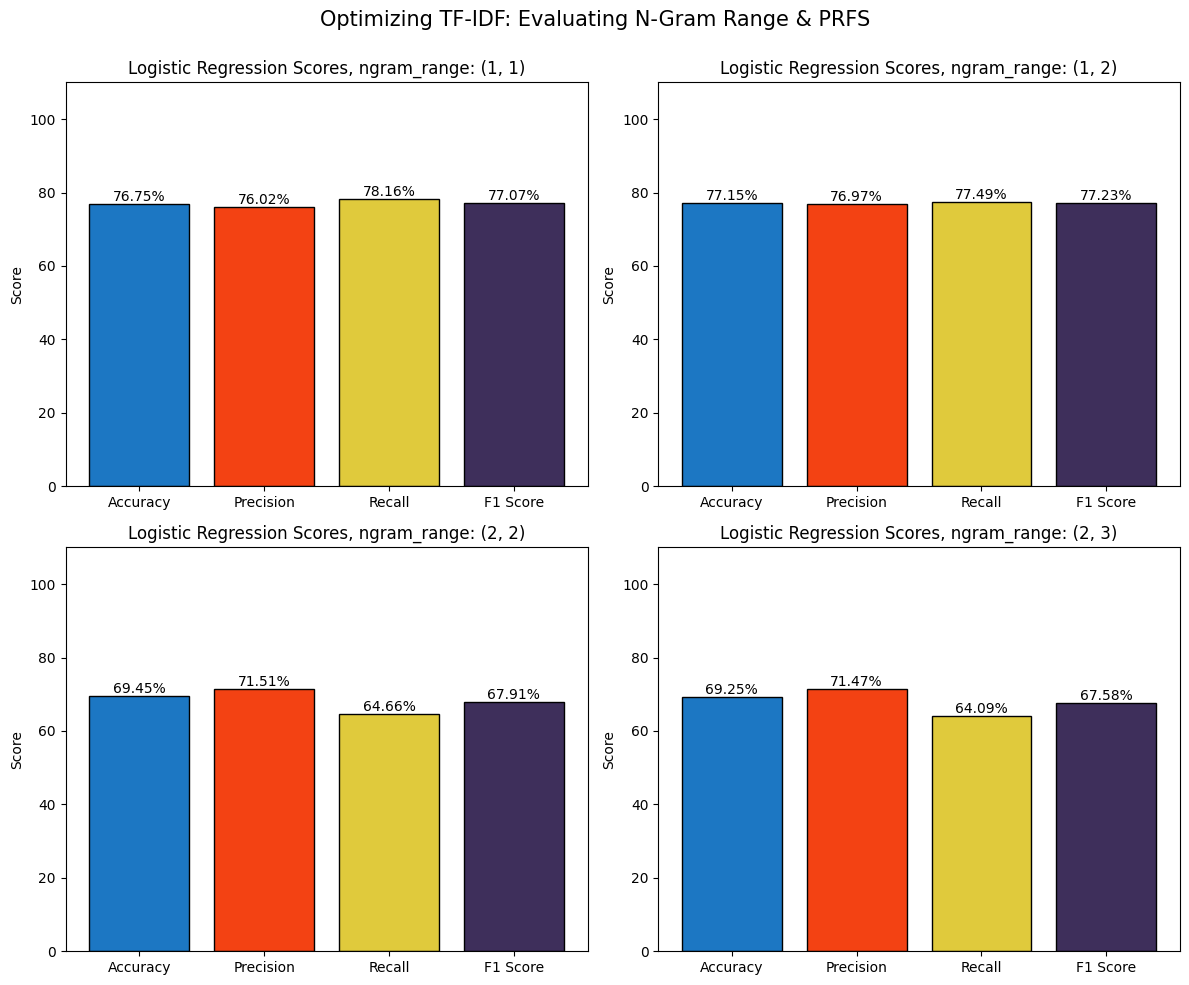

In [57]:
scores = test_tfidf(tfidf_params, X_train_prep, y_train_prep, X_val_prep, y_val_prep)
titles = [f"Logistic Regression Scores, {key}: {val}" for param in tfidf_params for key, val in param.items()]
title = 'Optimizing TF-IDF: Evaluating N-Gram Range & PRFS'
subplot_scores(scores, titles, title)

### Learning curve on the best `ngram_range: (1, 2)` hyperparameter configuration using the Training dataset **(PRFS)**

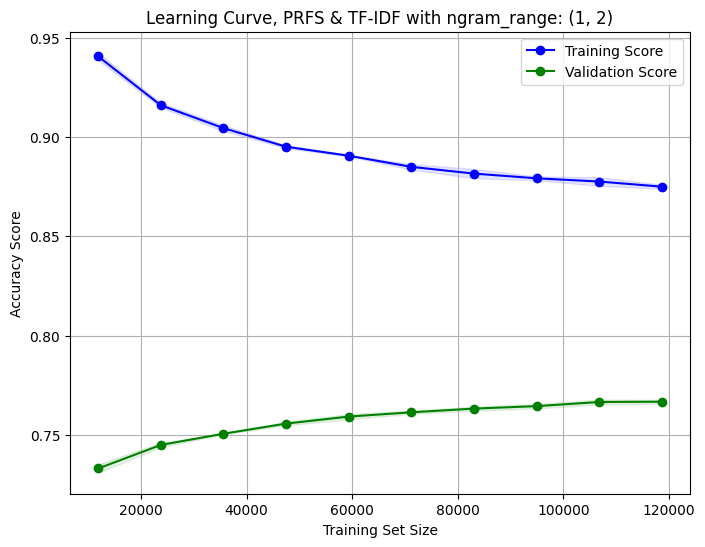

In [58]:
vectorizer = TfidfVectorizer(**tfidf_params[1])
X_train_tfidf = vectorizer.fit_transform(X_train_prep)

lc_res = calc_learning_curve(LogisticRegression(random_state=42, n_jobs=-1), X_train_tfidf, y_train_prep)
title = f'Learning Curve, PRFS & TF-IDF with {list(tfidf_params[1].keys())[0]}: {list(tfidf_params[1].values())[0]}'

plot_learning_curve(*lc_res, title)

### Experimenting on tweets preprocessing & preserving stop words **(PRPS)** on TF-IDF

#### Preprocessing again the datasets **without** removing stopwords from tweets

In [59]:
df_train_cln = clean_dataset(df_train, filter_stopwords=False)
df_val_cln = clean_dataset(df_val, filter_stopwords=False)
df_test_cln = clean_dataset(df_test, filter_stopwords=False, filter_rows=False)

X_train_prep, y_train_prep = df_train_cln['Text'], df_train_cln['Label']
X_val_prep, y_val_prep = df_val_cln['Text'], df_val_cln['Label']
X_test_prep = df_test_cln['Text']

In [60]:
print(f"X train Preprocessed Dimensions: {X_train_prep.shape}")
print(f"y train Preprocessed Dimensions: {y_train_prep.shape}")

print(f"X_val Preprocessed Dimensions: {X_val_prep.shape}")
print(f"y val Preprocessed Dimensions: {y_val_prep.shape}")

print(f"X test Preprocessed Dimensions: {X_test_prep.shape}")

X train Preprocessed Dimensions: (148388,)
y train Preprocessed Dimensions: (148388,)
X_val Preprocessed Dimensions: (42396,)
y val Preprocessed Dimensions: (42396,)
X test Preprocessed Dimensions: (21199,)


### Experimenting on TF-IDF `ngram_range` hyperparameter on preprocessed & preserved stopwords **(PRPS)**

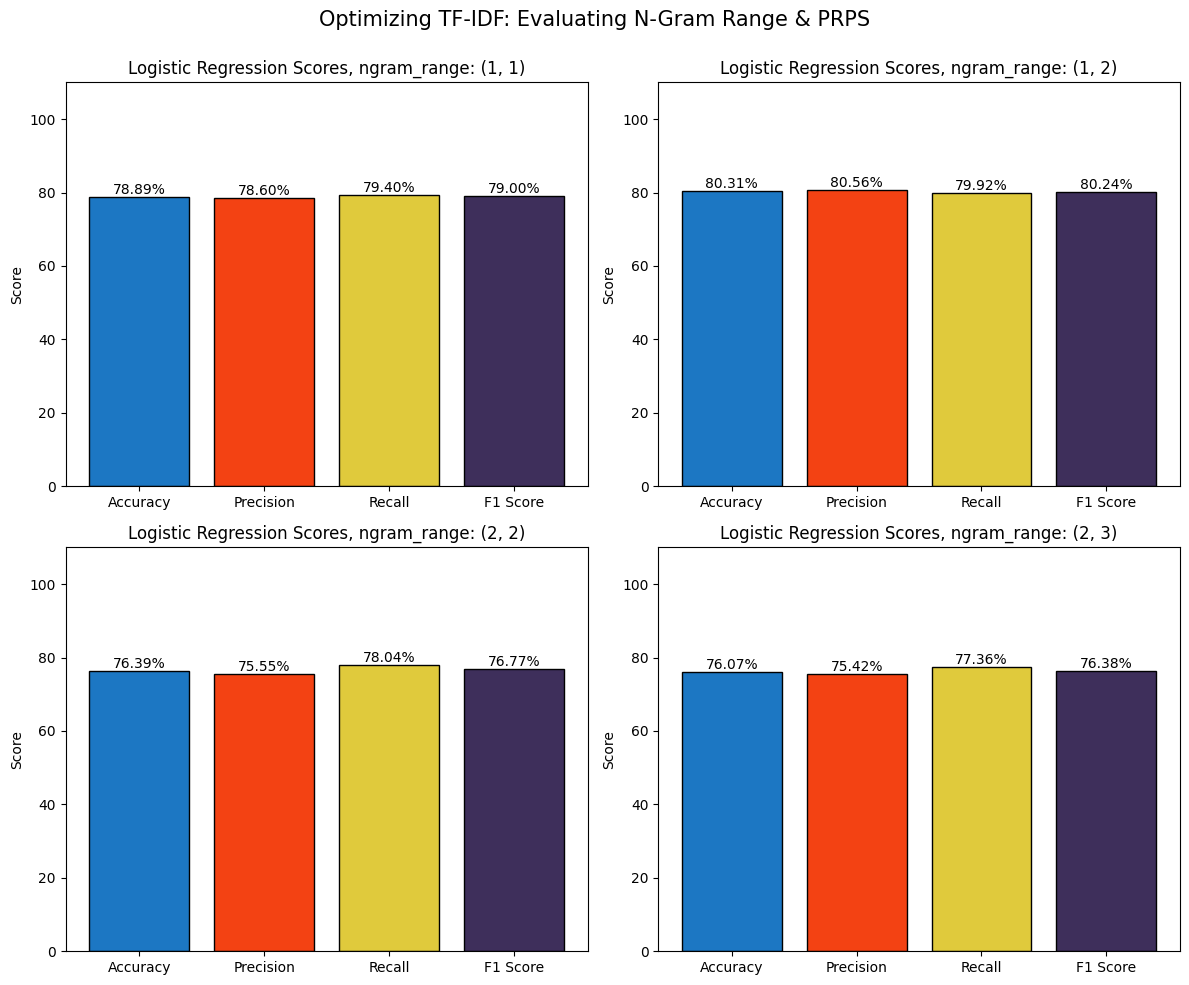

In [61]:
scores = test_tfidf(tfidf_params, X_train_prep, y_train_prep, X_val_prep, y_val_prep)
titles = [f"Logistic Regression Scores, {key}: {val}" for param in tfidf_params for key, val in param.items()]
title = 'Optimizing TF-IDF: Evaluating N-Gram Range & PRPS'
subplot_scores(scores, titles, title)

### Learning curve on the best `ngram_range: (1, 2)` hyperparameter configuration using the Training dataset **(PRPS)**

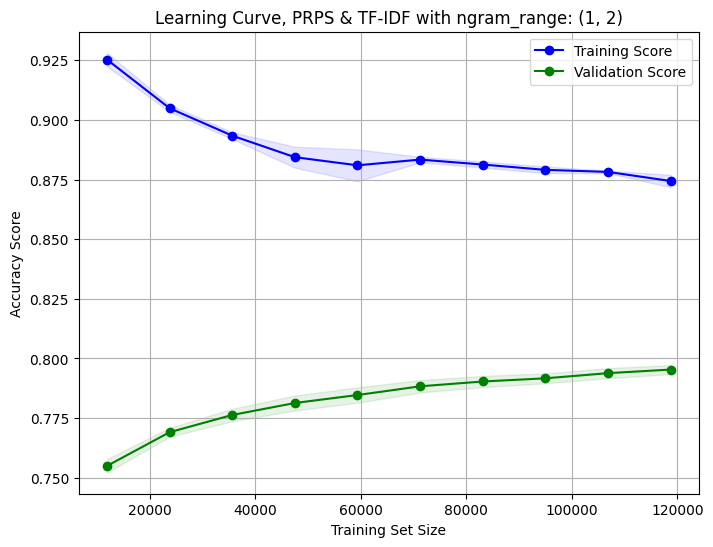

In [62]:
vectorizer = TfidfVectorizer(**tfidf_params[1])
X_train_tfidf = vectorizer.fit_transform(X_train_prep)

lc_res = calc_learning_curve(LogisticRegression(random_state=42, n_jobs=-1), X_train_tfidf, y_train_prep)
title = f'Learning Curve, PRPS & TF-IDF with {list(tfidf_params[1].keys())[0]}: {list(tfidf_params[1].values())[0]}'

plot_learning_curve(*lc_res, title)

### From the above graphs we conclude that PRPS (Preprocessing & Preserving Stop Words) is the optimal configuration using TF-IDF with `ngram_range: (1,2)` hyperparameter.

### Displaying the matrix dimensions of train set using the best `ngram_range (1, 2)` hyperparameter so far

In [63]:
vectorizer = TfidfVectorizer(**tfidf_params[1])
X_train_tfidf = vectorizer.fit_transform(X_train_prep)

print(f'Dimensions of TF-IDF classifier matrix on Train dataset: {X_train_tfidf.shape}')

Dimensions of TF-IDF classifier matrix on Train dataset: (148388, 641232)


### **Continuing the experimentation using the PRPS dataset from this point forward**

### Experimenting with `max_features` TF-IDF hyperparameter to reduce the dimensions

In [64]:
tfidf_params = [
    {'max_features': 200000, 'ngram_range': (1, 2)},
    {'max_features': 300000, 'ngram_range': (1, 2)},
    {'max_features': 400000, 'ngram_range': (1, 2)},
    {'max_features': 500000, 'ngram_range': (1, 2)}
]

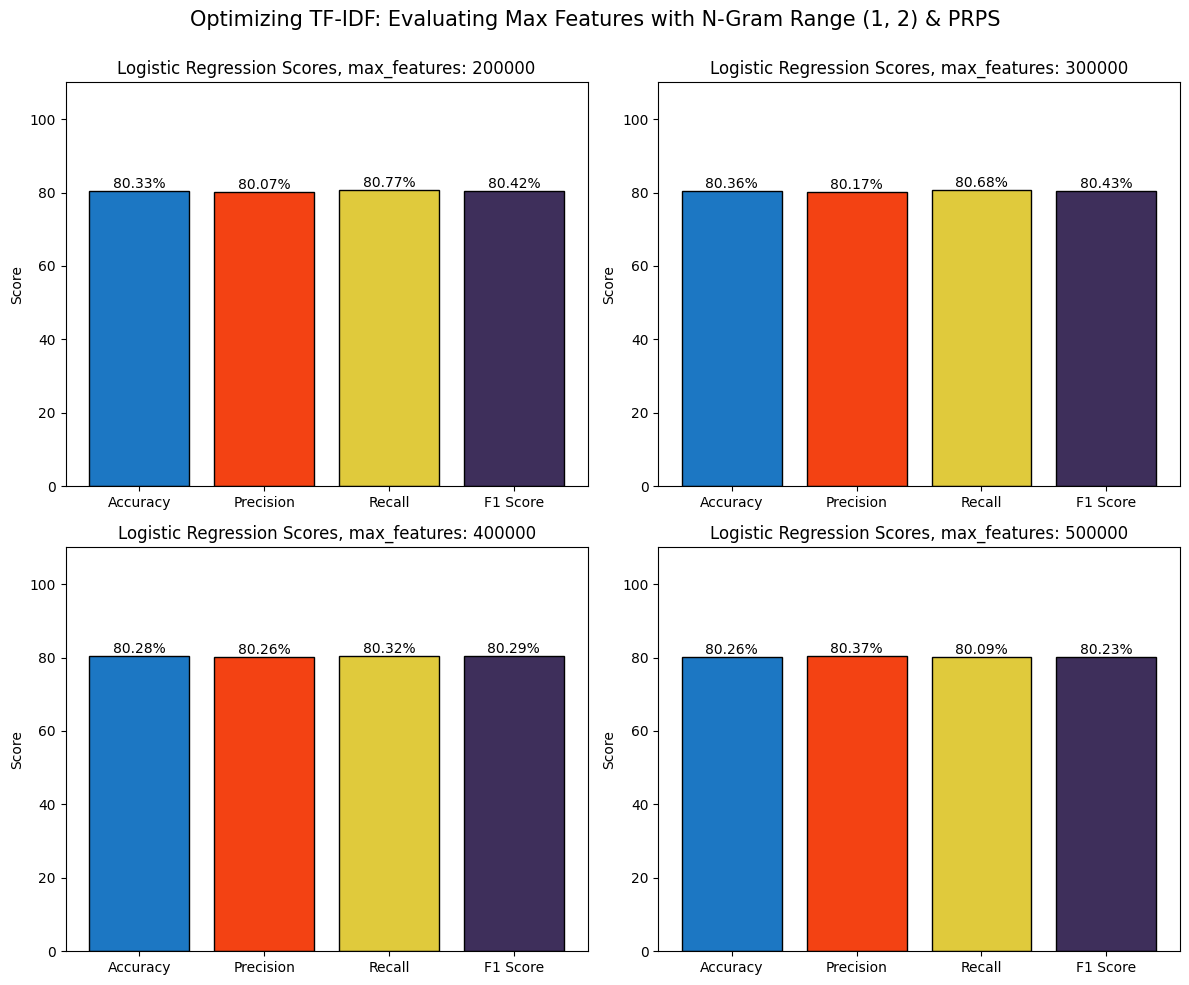

In [65]:
scores = test_tfidf(tfidf_params, X_train_prep, y_train_prep, X_val_prep, y_val_prep)
titles = [f"Logistic Regression Scores, max_features: {param['max_features']}" for param in tfidf_params]
title = 'Optimizing TF-IDF: Evaluating Max Features with N-Gram Range (1, 2) & PRPS'
subplot_scores(scores, titles, title)

### Learning curve on the best `max_features: 300000` & `ngram_range: (1, 2)` hyperparameter configuration using the Training dataset **(PRPS)**

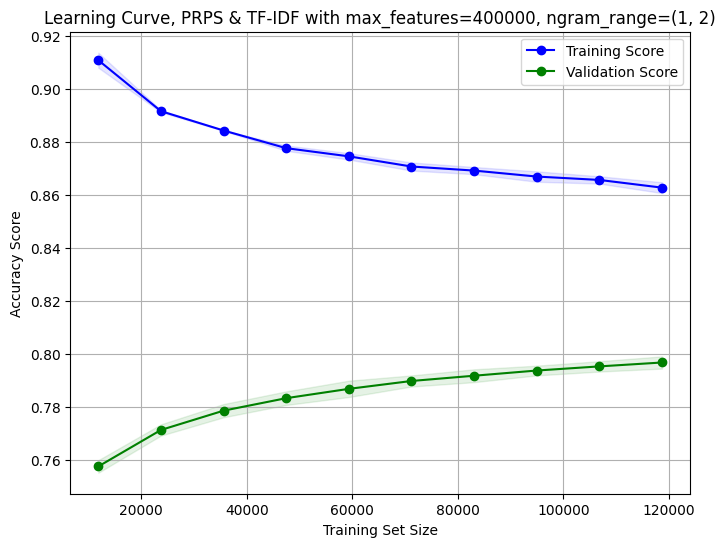

In [66]:
vectorizer = TfidfVectorizer(**tfidf_params[1])
X_train_tfidf = vectorizer.fit_transform(X_train_prep)

lc_res = calc_learning_curve(LogisticRegression(random_state=42, n_jobs=-1), X_train_tfidf, y_train_prep)
title = 'Learning Curve, PRPS & TF-IDF with ' + ', '.join(f'{key}={value}' for key, value in tfidf_params[2].items())

plot_learning_curve(*lc_res, title)

### Experimenting with `max_df` TF-IDF hyperparameter to ignore n-grams that appear more than a threshold

In [67]:
tfidf_params = [
    {**tfidf_params[1], 'max_df': 0.98},
    {**tfidf_params[1], 'max_df': 0.96},
    {**tfidf_params[1], 'max_df': 0.94},
    {**tfidf_params[1], 'max_df': 0.92},
]

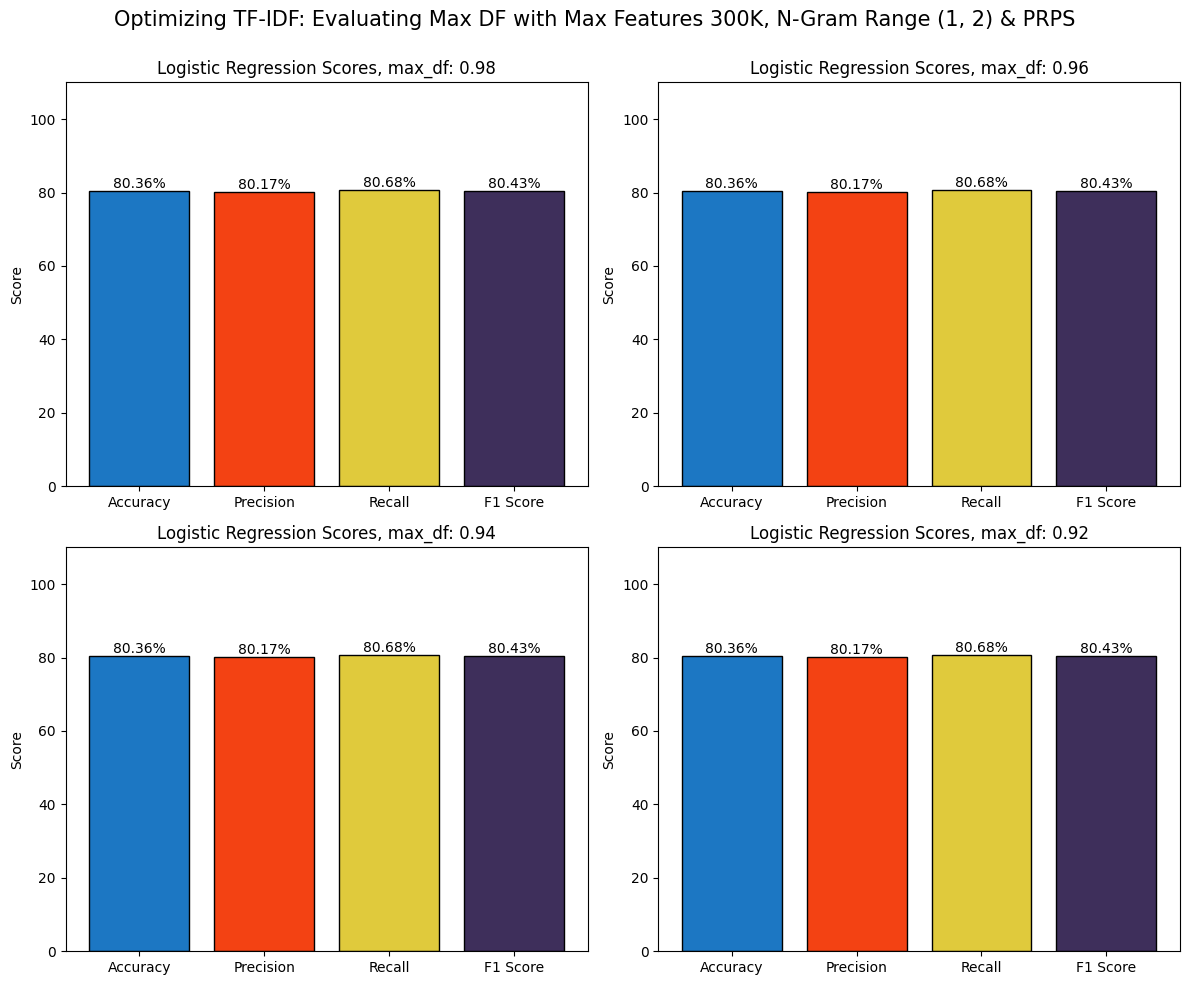

In [68]:
scores = test_tfidf(tfidf_params, X_train_prep, y_train_prep, X_val_prep, y_val_prep)
titles = [f"Logistic Regression Scores, max_df: {param['max_df']}" for param in tfidf_params]
title = 'Optimizing TF-IDF: Evaluating Max DF with Max Features 300K, N-Gram Range (1, 2) & PRPS'
subplot_scores(scores, titles, title)

### Hyperparameter `max_df` does not affect the scores on the validation set. **This parameter will not be used on the following experiments**.

#### Constructing the final TF-IDF matrix to experiment with logistic regression hyperparameters

### **The following TF-IDF configuration is the final & optimized model that will be used on Logistic Regression models**

In [69]:
optimized_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=300000)

X_train_tfidf = optimized_vectorizer.fit_transform(X_train_prep)
X_val_tfidf = optimized_vectorizer.transform(X_val_prep)
X_test_tfidf = optimized_vectorizer.transform(X_test_prep)

In [70]:
print(f'Dimensions of TF-IDF Train dataset classifier matrix: {X_train_tfidf.shape}')
print(f'Dimensions of TF-IDF Validation dataset classifier matrix: {X_val_tfidf.shape}')
print(f'Dimensions of TF-IDF Test dataset classifier matrix: {X_test_tfidf.shape}')

Dimensions of TF-IDF Train dataset classifier matrix: (148388, 300000)
Dimensions of TF-IDF Validation dataset classifier matrix: (42396, 300000)
Dimensions of TF-IDF Test dataset classifier matrix: (21199, 300000)


## Model Development and Evaluation

### Function that helps running experiments with Logistic Regression models

In [71]:
def test_logistic_regression(params, X_train, y_train, X_val, y_val):
    scores_list = []

    for param in params:
        logistic = LogisticRegression(random_state=42, n_jobs=-1, **param)

        logistic.fit(X_train, y_train)

        y_pred = logistic.predict(X_val)

        scores_list.append(calc_model_score(y_val, y_pred))

    return scores_list
    

### **Experimenting with multiple Logistic Regression solvers and all supported regularization methods (penalty)**
#### - **lbfgs**: L2 penalty
#### - **liblinear**: L1 & L2 penalty
#### - **newton-cg**: L2 penalty
#### - **sag**: L2 penalty
#### - **saga**: Elasticnet & L1 & L2 penalty

### Experimenting on **LBFGS** solver using L2 penalty

In [72]:
lr_params = [
    {'solver': 'lbfgs', 'penalty': 'l2'},
]

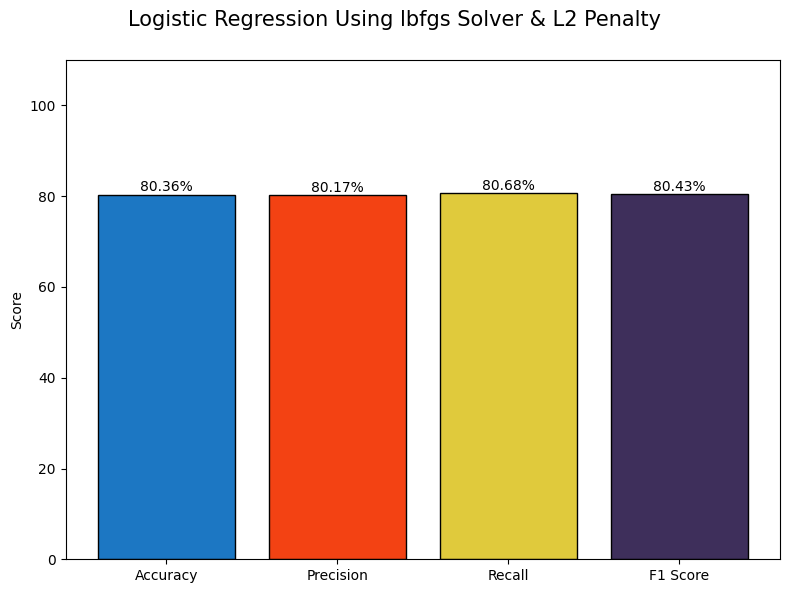

In [73]:
scores = test_logistic_regression(lr_params, X_train_tfidf, y_train_prep, X_val_tfidf, y_val_prep)
title = 'Logistic Regression Using lbfgs Solver & L2 Penalty'

subplot_scores(scores, [''], title, 1, 1, (8,6))

### Learning curve for **LBFGS** solver with L2 penalty

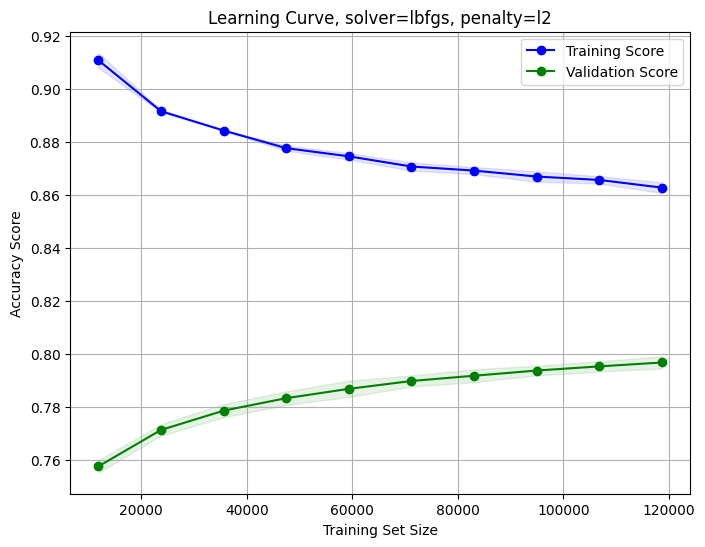

In [74]:
for param in lr_params:
    lc_res = calc_learning_curve(LogisticRegression(**param, random_state=42, n_jobs=-1), X_train_tfidf, y_train_prep)
    title = f'Learning Curve, ' + ', '.join(f'{key}={value}' for key, value in param.items())
    plot_learning_curve(*lc_res, title)

### Experimenting on **LibLinear** solver using L1 & L2 penalty

In [75]:
lr_params = [
    {'solver': 'liblinear', 'penalty': 'l1'},
    {'solver': 'liblinear', 'penalty': 'l2'}
]

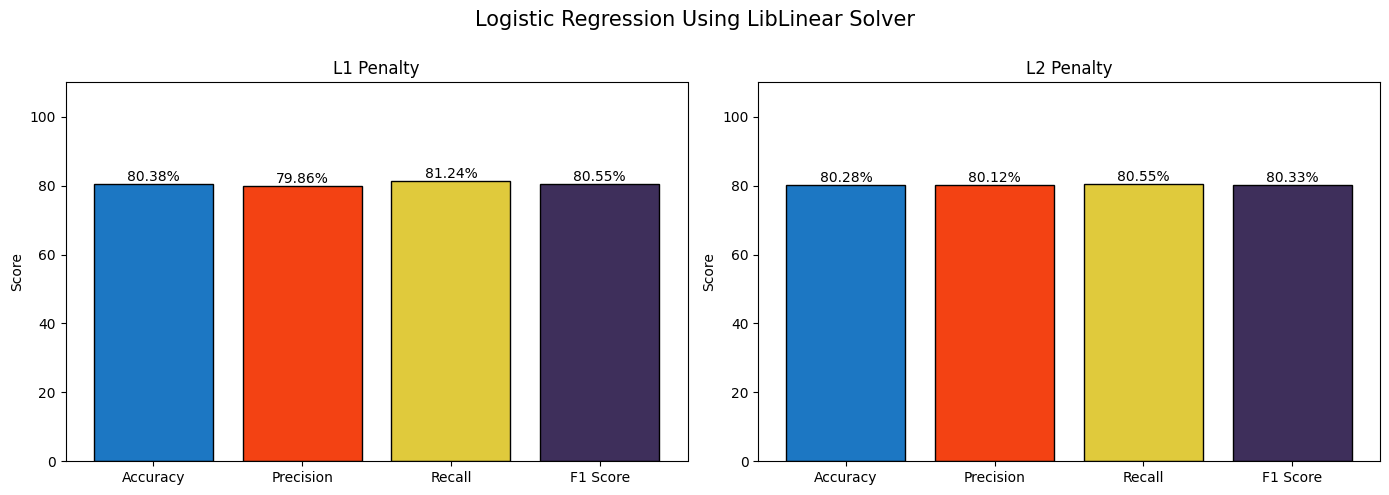

In [76]:
scores = test_logistic_regression(lr_params, X_train_tfidf, y_train_prep, X_val_tfidf, y_val_prep)
title = 'Logistic Regression Using LibLinear Solver'

subplot_scores(scores, ['L1 Penalty', 'L2 Penalty'], title, 1, 2, (14,5))

### Learning curve for **LibLinear** solver with L1 & L2 penalty

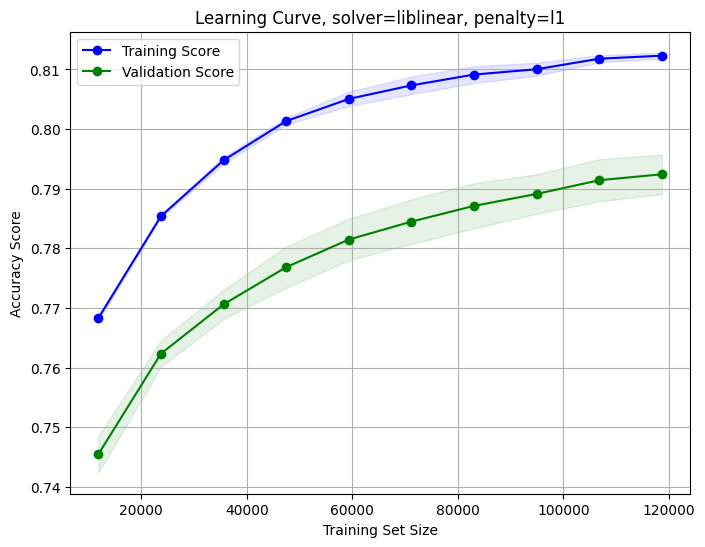

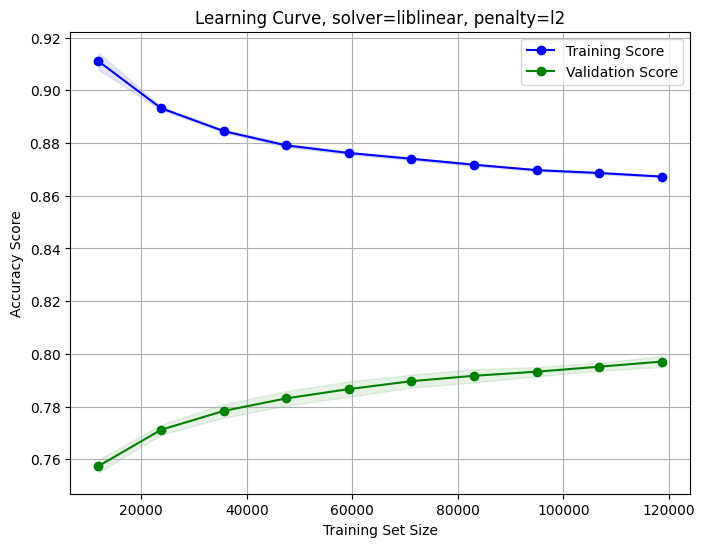

In [77]:
for param in lr_params:
    lc_res = calc_learning_curve(LogisticRegression(**param, random_state=42, n_jobs=-1), X_train_tfidf, y_train_prep)
    title = f'Learning Curve, ' + ', '.join(f'{key}={value}' for key, value in param.items())
    plot_learning_curve(*lc_res, title)

### Experimenting on **Newton-CG** solver using L2 penalty

In [78]:
lr_params = [
    {'solver': 'newton-cg', 'penalty': 'l2'},
]

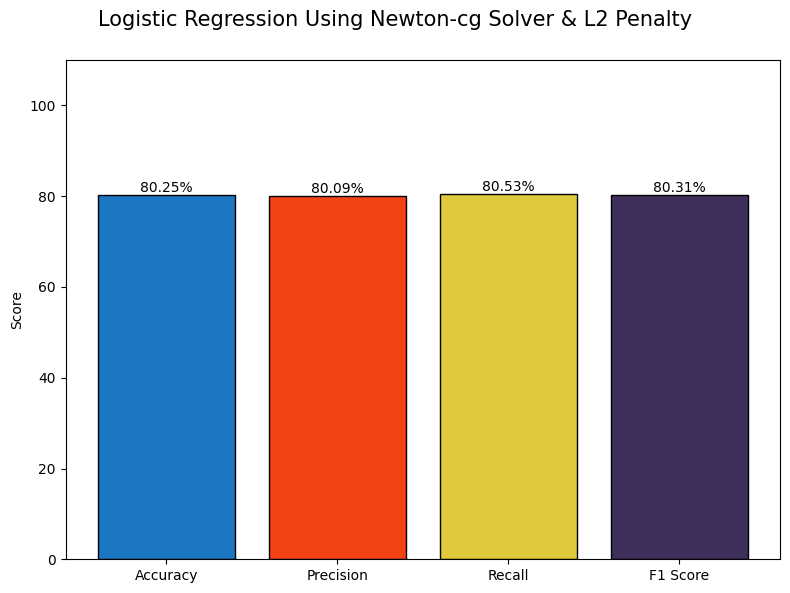

In [79]:
scores = test_logistic_regression(lr_params, X_train_tfidf, y_train_prep, X_val_tfidf, y_val_prep)
title = 'Logistic Regression Using Newton-cg Solver & L2 Penalty'

subplot_scores(scores, [''], title, 1, 1, (8,6))

### Learning curve for **Newton-CG** solver with L2 penalty

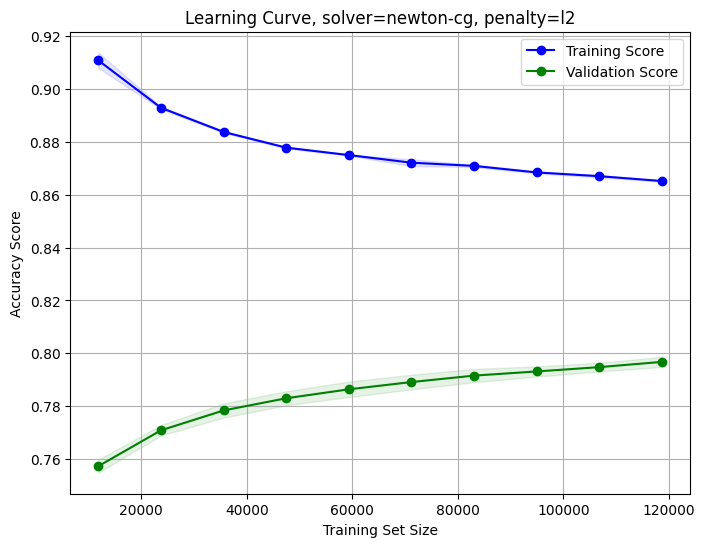

In [80]:
for param in lr_params:
    lc_res = calc_learning_curve(LogisticRegression(**param, random_state=42, n_jobs=-1), X_train_tfidf, y_train_prep)
    title = f'Learning Curve, ' + ', '.join(f'{key}={value}' for key, value in param.items())
    plot_learning_curve(*lc_res, title)

### Experimenting on **SAG** solver using L2 penalty

In [81]:
lr_params = [
    {'solver': 'sag', 'penalty': 'l2'},
]

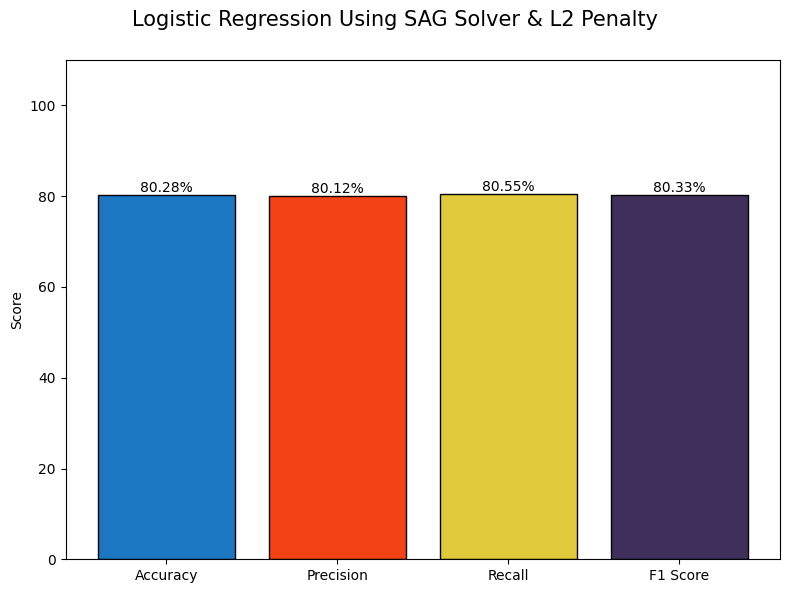

In [82]:
scores = test_logistic_regression(lr_params, X_train_tfidf, y_train_prep, X_val_tfidf, y_val_prep)
title = 'Logistic Regression Using SAG Solver & L2 Penalty'

subplot_scores(scores, [''], title, 1, 1, (8,6))

### Learning curve for **SAG** solver with L2 penalty

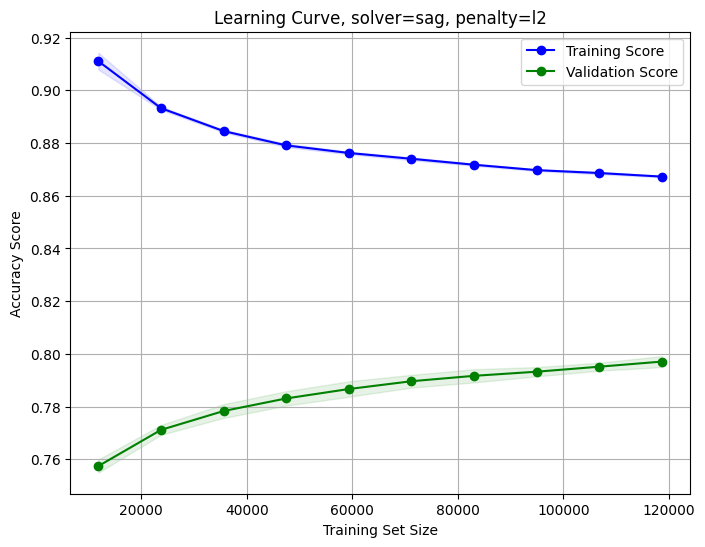

In [83]:
for param in lr_params:
    lc_res = calc_learning_curve(LogisticRegression(**param, random_state=42, n_jobs=-1), X_train_tfidf, y_train_prep)
    title = f'Learning Curve, ' + ', '.join(f'{key}={value}' for key, value in param.items())
    plot_learning_curve(*lc_res, title)

### Experimenting on **SAGA** solver using L1, L2 & Elasticnet penalty

In [84]:
lr_params = [
    {'solver': 'saga', 'penalty': 'l1'},
    {'solver': 'saga', 'penalty': 'l2'},
    {'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.5},
]

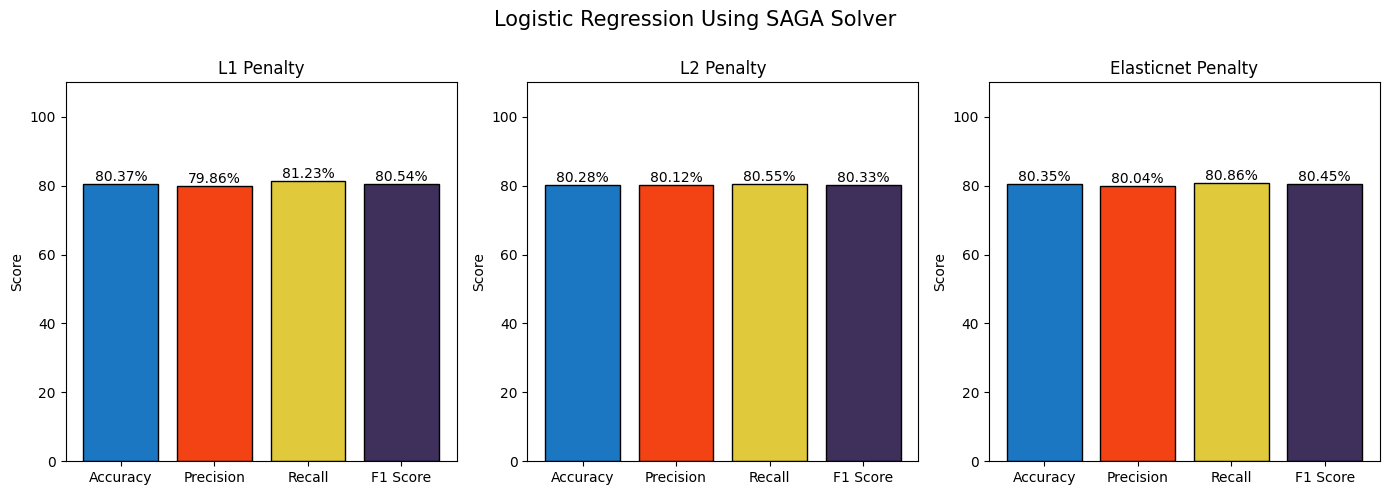

In [85]:
scores = test_logistic_regression(lr_params, X_train_tfidf, y_train_prep, X_val_tfidf, y_val_prep)
title = 'Logistic Regression Using SAGA Solver'

subplot_scores(scores, ['L1 Penalty', 'L2 Penalty', 'Elasticnet Penalty'], title, 1, 3, (14,5))

### Learning curve for **SAGA** solver with L1, L2 & Elasticnet penalty

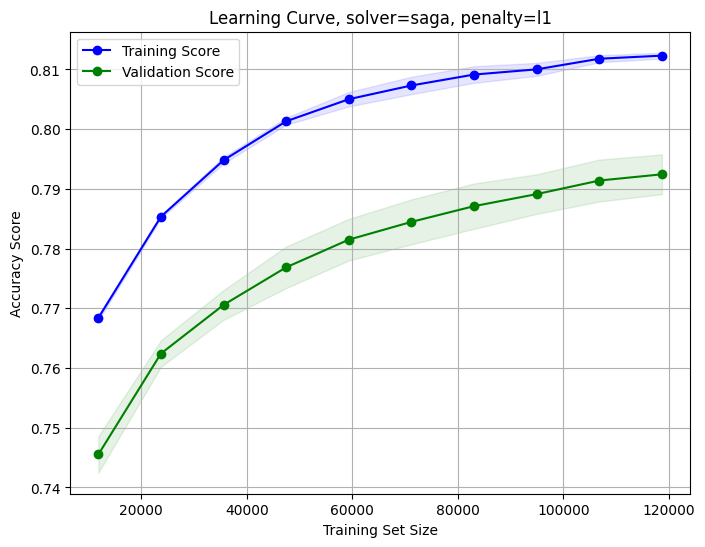

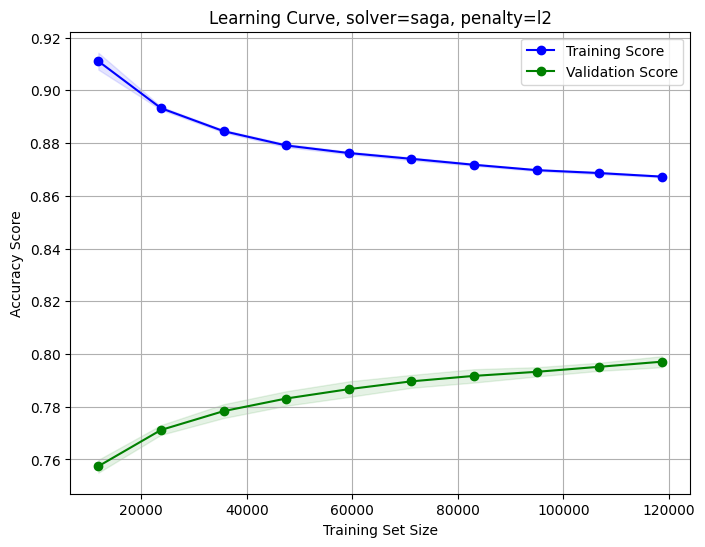

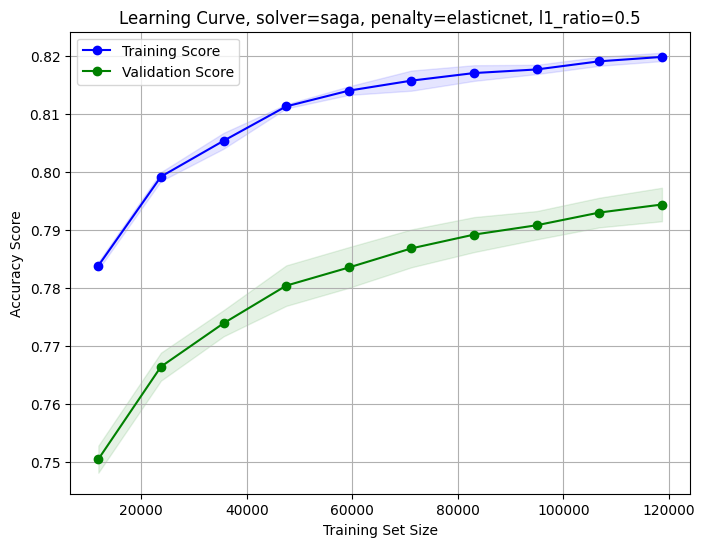

In [86]:
for param in lr_params:
    lc_res = calc_learning_curve(LogisticRegression(**param, random_state=42, n_jobs=-1), X_train_tfidf, y_train_prep)
    title = f'Learning Curve, ' + ', '.join(f'{key}={value}' for key, value in param.items())
    plot_learning_curve(*lc_res, title)

### Running cross-validation to experiment on `C`, `max_iter` and `l1_ratio` (on Elasticnet) using the above Logistic Regression solvers, excluding configurations where `C=1` (the default value) introduced overfitting problems, to increase the model's generalization and avoid overfitting issues.

In [87]:
def get_results(model_results):
    model_rows = []
    for results in model_results:
        
        params_df =  pd.DataFrame([results['Best Parameters']])
        
        percentage_vals = dict((k, f'{v * 100:.5}%') for k, v in results['Scores'].items())
        scores_df = pd.DataFrame([percentage_vals])
        
        combined_df = pd.concat([params_df, scores_df], axis=1)
        
        model_rows.append(combined_df)
    
    return pd.concat(model_rows, ignore_index=True)

In [88]:
parameters_grid = [
    {
        'C': [0.001, 0.01, 0.1],
        'max_iter': [100, 200, 300],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    {
        'C': [0.001, 0.01, 0.1, 1],
        'max_iter': [100, 200, 300],
        'penalty': ['l1'],
        'solver': ['liblinear']
    },
    {
        'C': [0.001, 0.01, 0.1],
        'max_iter': [100, 200, 300],
        'penalty': ['l2'],
        'solver': ['liblinear']
    },
    {
        'C': [0.001, 0.01, 0.1],
        'max_iter': [100, 200, 300],
        'penalty': ['l2'],
        'solver': ['newton-cg']
    },
    {
        'C': [0.001, 0.01, 0.1],
        'max_iter': [100, 200, 300],
        'penalty': ['l2'],
        'solver': ['sag']
    },
    {
        'C': [0.001, 0.01, 0.1, 1],
        'max_iter': [100, 200, 300],
        'penalty': ['l1'],
        'solver': ['saga']
    },
    {
        'C': [0.001, 0.01, 0.1],
        'max_iter': [100, 200, 300],
        'penalty': ['l2'],
        'solver': ['saga']
    },
    {
        'C': [0.001, 0.01, 0.1, 1],
        'l1_ratio': [0.3, 0.4, 0.5, 0.6],
        'max_iter': [100, 200, 300],
        'penalty': ['elasticnet'],
        'solver': ['saga']
    }
]

### Running GridSearchCV with `cv=5`, calculating the **accuracy**, **precision**, **recall** & **f1** scores for each optimized (on hyperparameters) model

In [89]:
logistic_reg = LogisticRegression(random_state=42, n_jobs=-1)

models_results = []

for params in parameters_grid:
    
    grid_search = GridSearchCV(logistic_reg, params, cv=5, scoring='accuracy', n_jobs=-1)
    
    grid_search.fit(X_train_tfidf, y_train_prep)
    
    y_val_pred = grid_search.predict(X_val_tfidf)
    
    models_results.append({
        'Best Parameters': grid_search.best_params_,
        'Best Estimator': grid_search.best_estimator_,
        'Scores': calc_model_score(y_val, y_val_pred)
    })

display(get_results(models_results))

,C,max_iter,penalty,solver,Accuracy,Precision,Recall,F1 Score,l1_ratio
0,0.1,100,l2,lbfgs,78.069%,77.927%,78.324%,78.125%,NaN
1,1.0,100,l1,liblinear,80.378%,79.865%,81.24%,80.546%,NaN
2,0.1,100,l2,liblinear,78.062%,77.99%,78.192%,78.091%,NaN
3,0.1,100,l2,newton-cg,77.986%,77.87%,78.197%,78.033%,NaN
4,0.1,100,l2,sag,78.062%,77.99%,78.192%,78.091%,NaN
5,1.0,100,l1,saga,80.373%,79.86%,81.235%,80.542%,NaN
6,0.1,100,l2,saga,78.059%,77.986%,78.192%,78.089%,NaN
7,1.0,100,elasticnet,saga,80.394%,80.17%,80.768%,80.468%,0.3


### Displaying the **most optimized cross-validation model** (based on the accuracy metric)

In [90]:
lr_best_model_data = max(models_results, key=lambda v: v['Scores']['Accuracy'])

lr_best_model = lr_best_model_data['Best Estimator']

print(lr_best_model)

LogisticRegression(C=1, l1_ratio=0.3, n_jobs=-1, penalty='elasticnet',
                   random_state=42, solver='saga')


In [91]:
best_parameters = lr_best_model_data['Best Parameters']
display(pd.DataFrame([best_parameters]))

,C,l1_ratio,max_iter,penalty,solver
0,1,0.3,100,elasticnet,saga


### Plotting the validation set scores using the most optimized cross-validation model

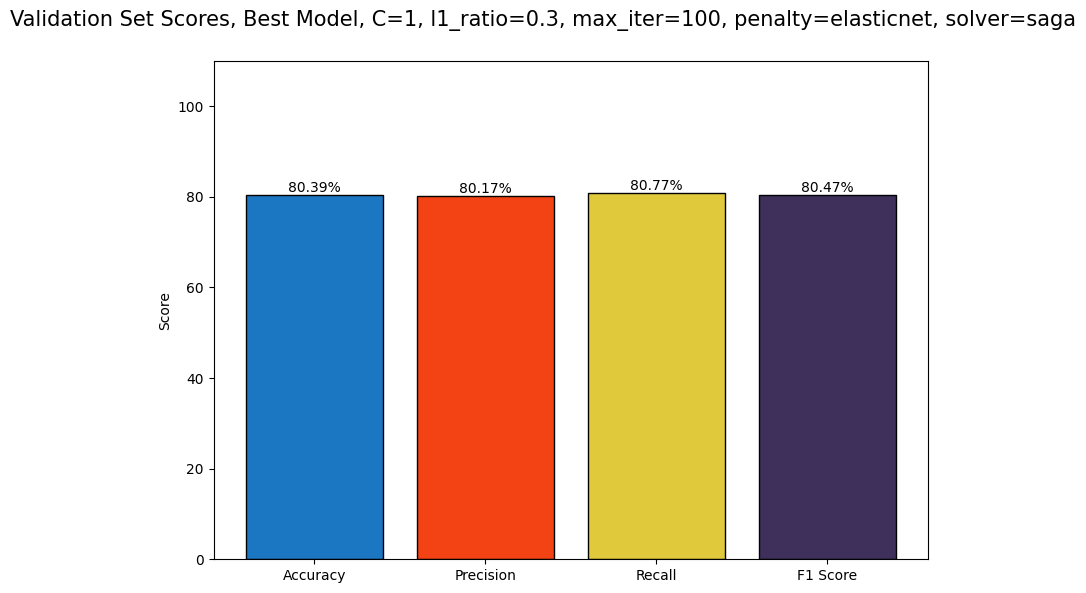

In [92]:
scores = lr_best_model_data['Scores']
title = f'Validation Set Scores, Best Model, ' + ', '.join(f'{key}={value}' for key, value in best_parameters.items())
subplot_scores([scores], [''], title, 1, 1, (8,6))

### Plotting the learning curve using the best cross-validation model calulated using the `GridSearchCV`

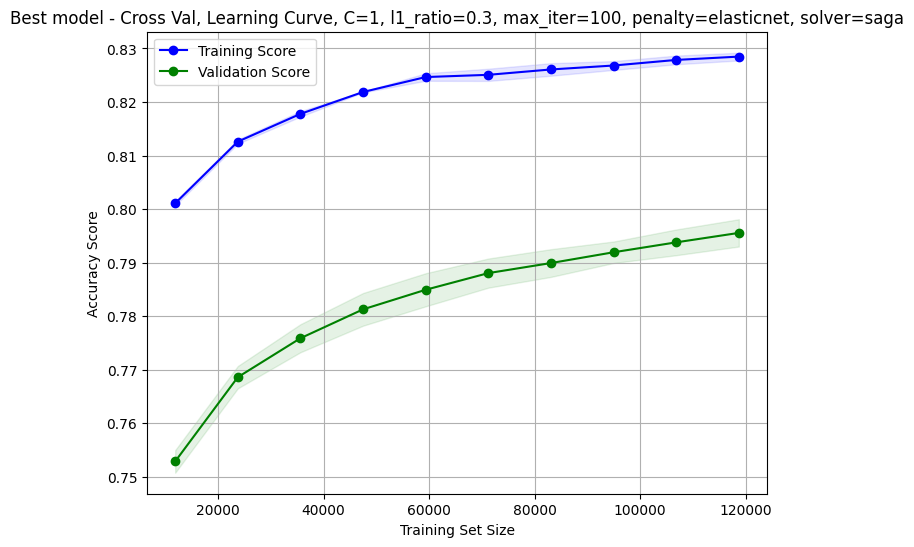

In [93]:
lc_res = calc_learning_curve(lr_best_model, X_train_tfidf, y_train_prep)
title = f'Best model - Cross Val, Learning Curve, ' + ', '.join(f'{key}={value}' for key, value in best_parameters.items())
plot_learning_curve(*lc_res, title)

### Recalculating the predicted labels from validation set to plot ROC curve & Confusion matrix

In [94]:
y_val_pred = lr_best_model.predict(X_val_tfidf)

### Calculating & plotting the ROC curve graph

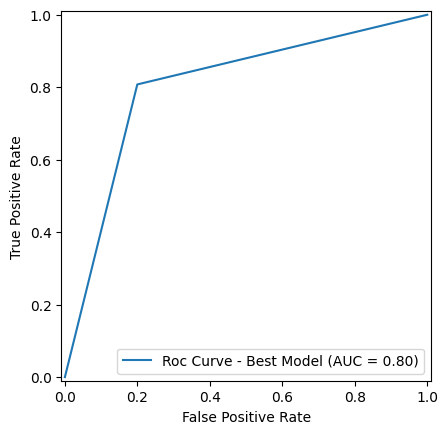

In [95]:
plot_roc_curve(*calc_roc_curve(y_val_prep, y_val_pred), "Roc Curve - Best Model")

### Calculating and plotting confusion matrix

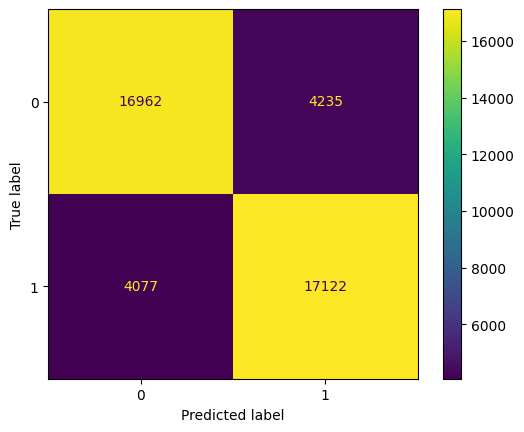

In [96]:
plot_confusion_matrix(calc_confusion_matrix(y_val_prep, y_val_pred, lr_best_model), lr_best_model)

### Making the label predictions on Test set using the most optimized cross-validation model

In [97]:
y_test_pred = lr_best_model.predict(X_test_tfidf)

### Storing the label predictions among with the tweet IDs in a CSV file

In [98]:
pd.DataFrame({
    'ID': df_test['ID'],
    'Label': y_test_pred
}).to_csv('submission.csv', index=False)